<center>

## Calibration with NiO Angle
</center>

In [ ]:
# ================================================================================================== Import =================================================================================================================
import re
import hyperspy.api as hs
import matplotlib.pyplot as plt
import numpy as np
import math
from k_factors import k_factors
from scipy.optimize import curve_fit
from datetime import datetime
from pathlib import Path
from matplotlib.ticker import MultipleLocator

In [9]:
# ==================================================================================================Load Data with Path ==================================================================================================

MainPath = Path.cwd()

folder = MainPath / "NiO_Angles"
PlotPath = MainPath / "Plots"

def extract_angle(filepath):
    name = Path(filepath).stem
    match = re.search(r'([+-]?\d+(?:\.\d+)?)Deg', name)
    
    if match is None:
        raise ValueError(f"Could not extract angle from filename: {name}")
    return float(match.group(1))

# load and SORT files by angle
files = sorted(folder.glob("*.msa"), key=extract_angle)
s = hs.load(files[5]) # Load one spectrum to identify peaks and set elements/lines for all spectra

C:\Users\grego\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\grego\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\hyperspy\misc\_utils.py:1590: VisibleDeprecationWarning: Importing `LazyComplexSignal1D` from `hyperspy._signals.complex_signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
C:\Users\grego\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\hyperspy\misc\_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is depre

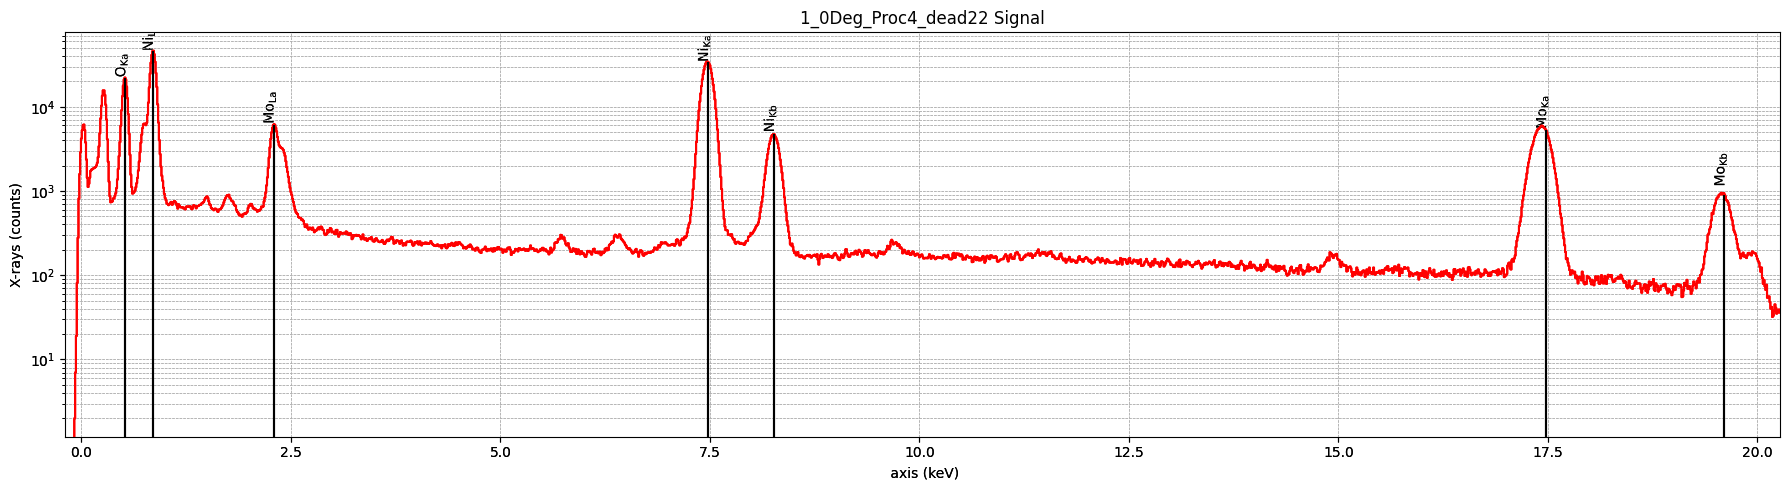

In [10]:
# ================================================================================================== Identify Peaks =================================================================================================================

s.set_elements(['O', 'Ni', 'Mo'])
s.set_lines(['O_Ka', 'Ni_Ka', 'Ni_Kb', 'Ni_La', 'Mo_Ka', 'Mo_Kb', 'Mo_La'])

s.plot(True)
fig = plt.gcf()
ax = plt.gca()
ax.grid(True, which="both", ls="--", lw=0.5)
ax.set_yscale("log") # Set y-axis to "linear", "log" or"symlog", scale for better visibility of peaks
fig.set_size_inches(18, 5)
fig.tight_layout()
    



<center>

# Background Window Positioning
</center>

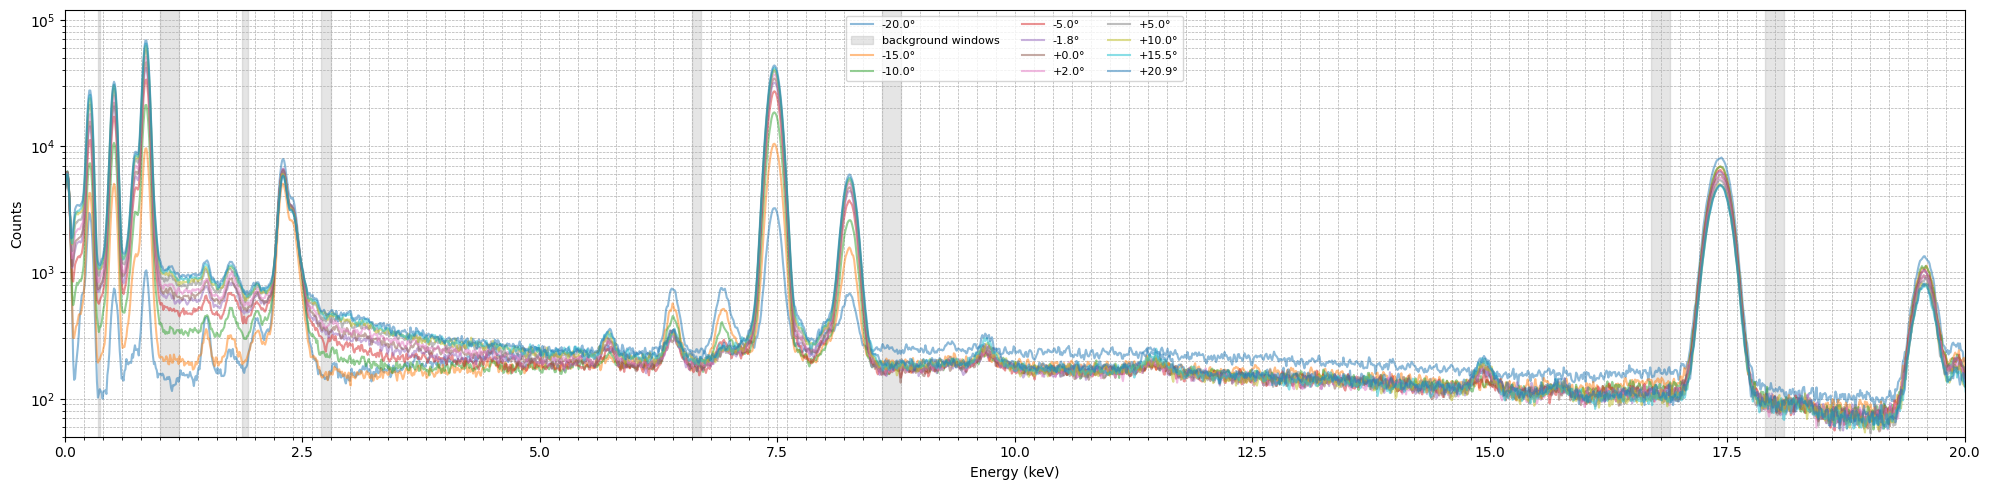

In [11]:
# ================================================================================================== Background Windows =================================================================================================================

fig, ax = plt.subplots(figsize=(20, 5))

for i, f in enumerate(files):
    s = hs.load(f)
    s.set_signal_type("EDS_TEM")
    s.set_elements(['O', 'Ni', 'Mo'])
    s.set_lines(['O_Ka', 'Ni_Ka', 'Ni_Kb', 'Mo_Ka'])

    x = s.axes_manager.signal_axes[0].axis
    y = s.data.astype(float)

    # O_Ka
    lmin_O, lmax_O = 0.35, 0.37
    rmin_O, rmax_O = 1.0, 1.2

    # Ni_Ka / Ni_Kb
    lmin_Ni, lmax_Ni = 6.6, 6.7
    rmin_Ni, rmax_Ni = 8.6, 8.8

    # Mo_Ka
    lmin_Mo, lmax_Mo = 16.7, 16.9
    rmin_Mo, rmax_Mo = 17.9, 18.1

    # Mo_La
    lmin_Mo_La, lmax_Mo_La = 1.87, 1.93
    rmin_Mo_La, rmax_Mo_La = 2.7, 2.8

    # # Exact windows used for Background estimation
    # x_Ni_bg_left = 7.28
    # x_Ni_bg_right = 7.65

    angle = extract_angle(f)

    ax.plot(x, y, label=f"{angle:+}°", alpha=0.5)

    # draw bw only once, because they are identical for all spectra
    if i == 0:
        # Ni peak windows
        ax.axvspan(lmin_Ni, lmax_Ni, color="grey", alpha=0.2, label="background windows")
        ax.axvspan(rmin_Ni, rmax_Ni, color="grey", alpha=0.2)

        # O peak windows
        ax.axvspan(lmin_O, lmax_O, color="grey", alpha=0.2)
        ax.axvspan(rmin_O, rmax_O, color="grey", alpha=0.2)

        # Mo peak windows
        ax.axvspan(lmin_Mo, lmax_Mo, color="grey", alpha=0.2)
        ax.axvspan(rmin_Mo, rmax_Mo, color="grey", alpha=0.2)

        # Mo_La peak windows
        ax.axvspan(lmin_Mo_La, lmax_Mo_La, color="grey", alpha=0.2)
        ax.axvspan(rmin_Mo_La, rmax_Mo_La, color="grey", alpha=0.2)

        # # Ni background windows
        # ax.axvline(x_Ni_bg_left, color="black", linestyle="--", label="Ni background windows")
        # ax.axvline(x_Ni_bg_right, color="black", linestyle="--") 

ax.set_yscale("log")
ax.set_ylim(bottom=50) # Set y-axis limits to better visualize peaks, adjust as needed
ax.xaxis.set_minor_locator(MultipleLocator(0.2))
ax.grid(True, which="both", ls="--", lw=0.5)
ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")
ax.set_xlim(0,20) # Set x-axis limits to focus on relevant energy range, adjust as needed
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
plt.show()

Keep Track of the -20 Degree line. 

Lower Energys almost not representable -> To much absorbtion

Higher Energys over representablet -> ???

<center>

# Gaussien Composition & Peak Area Calculation
</center>
Each peak needs 10^4 counts after Background substraction to be a good peak according to Willliams & Cater

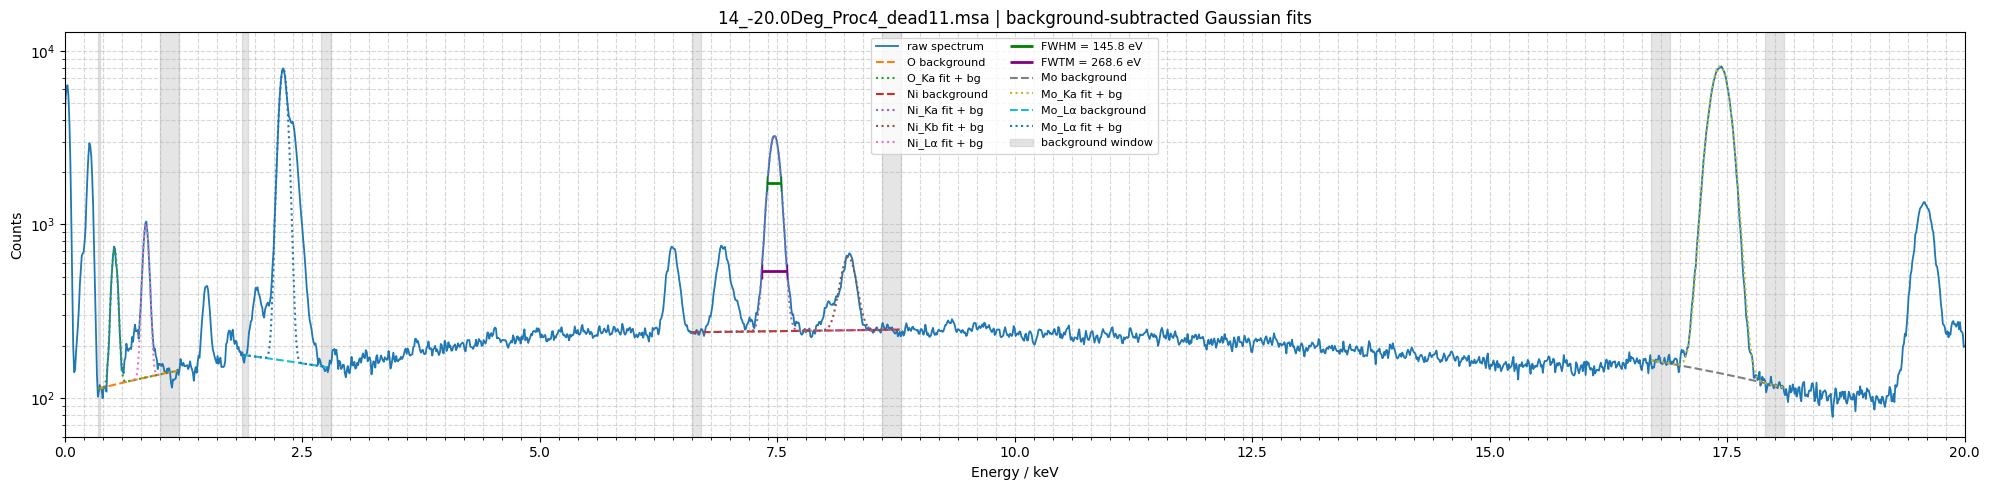

14_-20.0Deg_Proc4_dead11.msa O_Ka=0.5244 keV, Ni_Ka=7.4707 keV, Ni_Kb=8.2481 keV, Ni_La=0.8556 keV, Mo_Ka=17.4232 keV, Mo_La=2.3020 keV, O_Ka=4707.9 Counts/Peak, Ni_Ka=46370.6 Counts/Peak, Ni_Kb=7871.9 Counts/Peak, Ni_La=6966.9 Counts/Peak, Mo_Ka=209179.9 Counts/Peak, Mo_La=83663.5 Counts/Peak


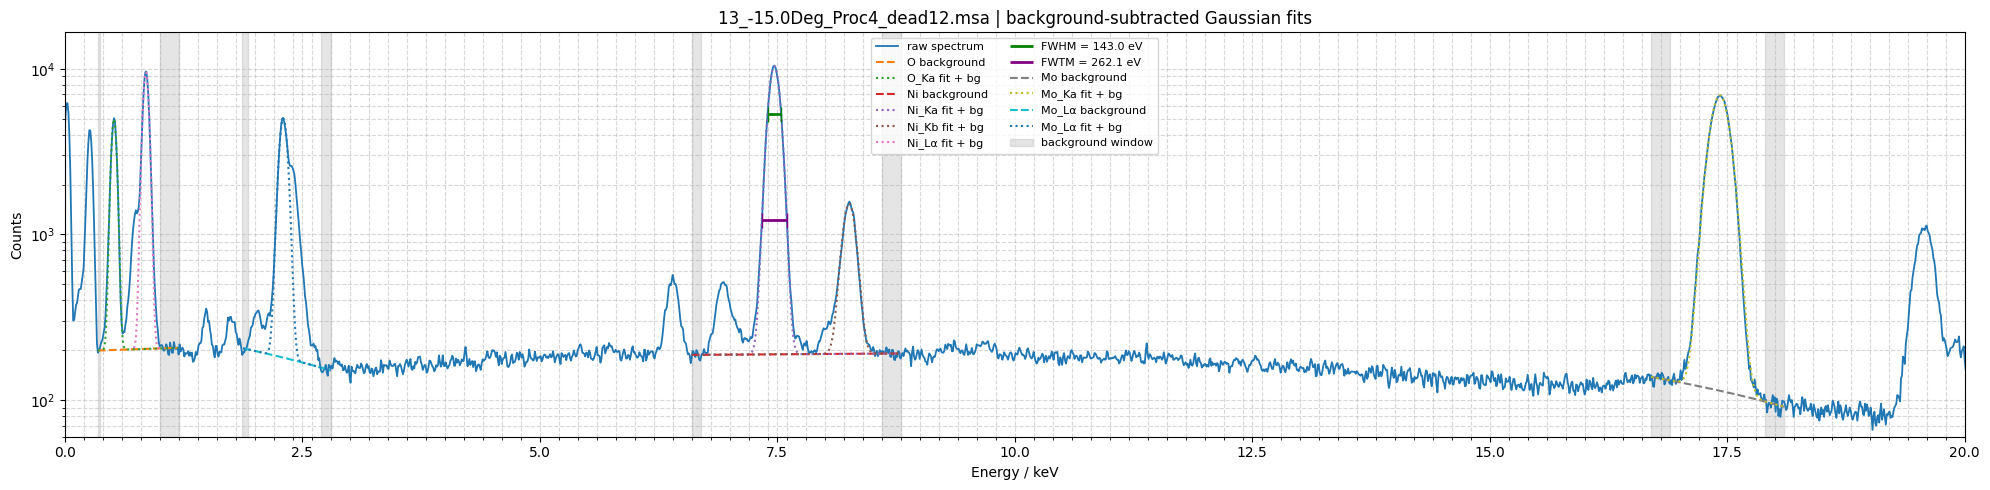

13_-15.0Deg_Proc4_dead12.msa O_Ka=0.5192 keV, Ni_Ka=7.4704 keV, Ni_Kb=8.2578 keV, Ni_La=0.8551 keV, Mo_Ka=17.4225 keV, Mo_La=2.3018 keV, O_Ka=34477.2 Counts/Peak, Ni_Ka=156416.0 Counts/Peak, Ni_Kb=22931.2 Counts/Peak, Ni_La=74205.2 Counts/Peak, Mo_Ka=177305.5 Counts/Peak, Mo_La=54039.0 Counts/Peak


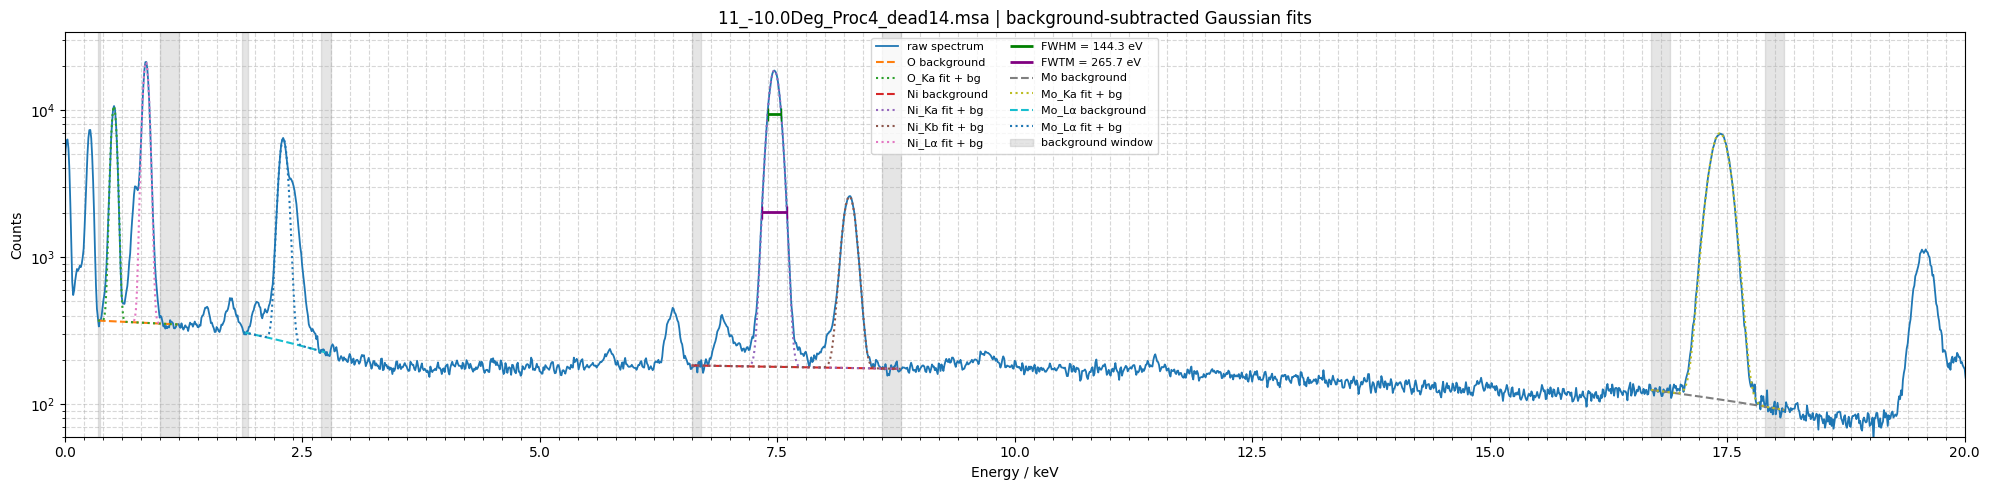

11_-10.0Deg_Proc4_dead14.msa O_Ka=0.5188 keV, Ni_Ka=7.4709 keV, Ni_Kb=8.2600 keV, Ni_La=0.8553 keV, Mo_Ka=17.4225 keV, Mo_La=2.3021 keV, O_Ka=74021.5 Counts/Peak, Ni_Ka=282588.4 Counts/Peak, Ni_Kb=40557.6 Counts/Peak, Ni_La=163926.9 Counts/Peak, Mo_Ka=177707.3 Counts/Peak, Mo_La=68365.2 Counts/Peak


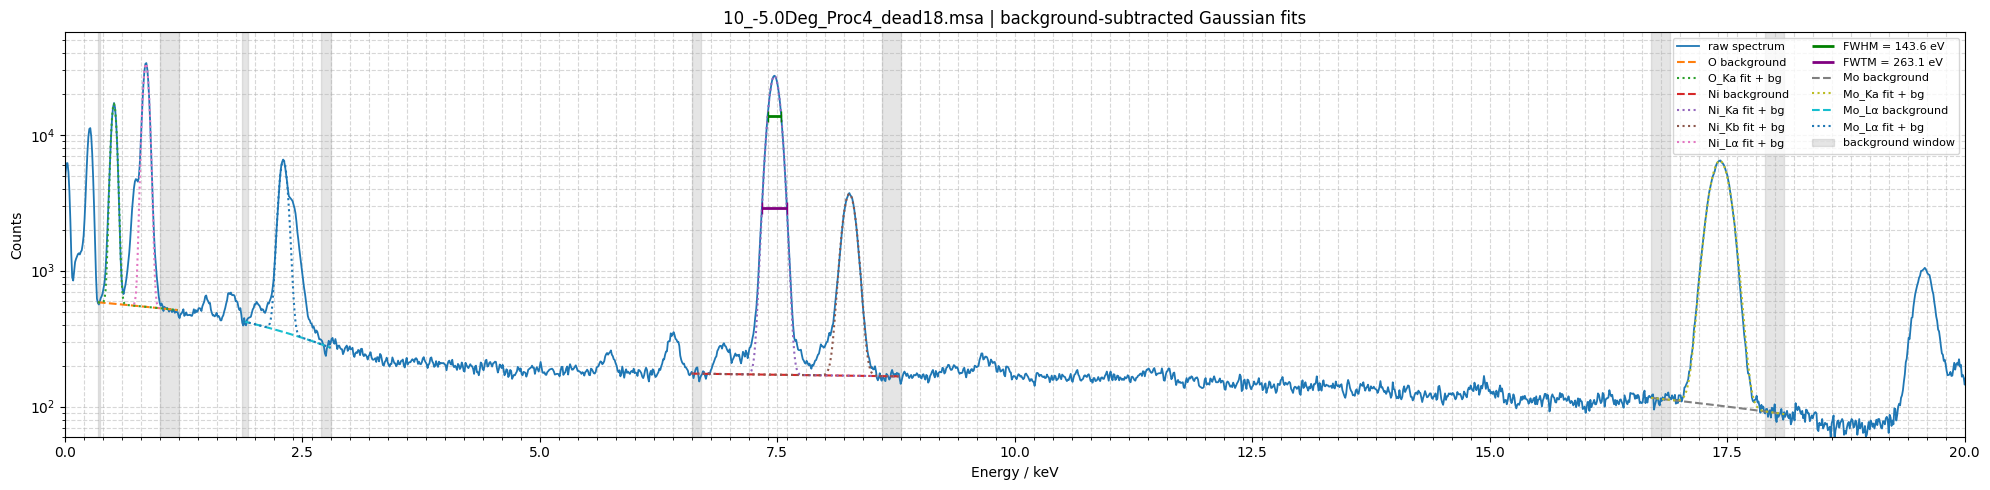

10_-5.0Deg_Proc4_dead18.msa O_Ka=0.5188 keV, Ni_Ka=7.4711 keV, Ni_Kb=8.2600 keV, Ni_La=0.8555 keV, Mo_Ka=17.4227 keV, Mo_La=2.3021 keV, O_Ka=116806.9 Counts/Peak, Ni_Ka=413282.5 Counts/Peak, Ni_Kb=59796.3 Counts/Peak, Ni_La=261304.0 Counts/Peak, Mo_Ka=165776.0 Counts/Peak, Mo_La=67546.7 Counts/Peak


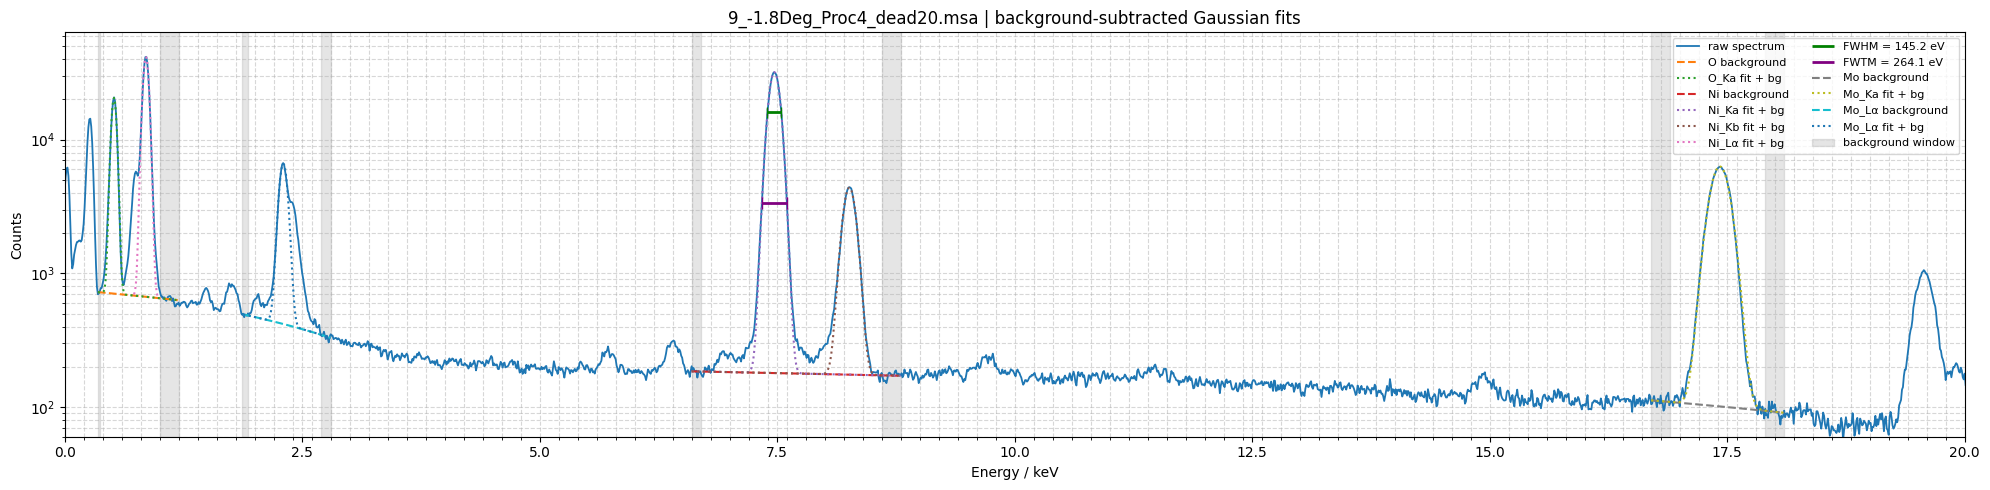

9_-1.8Deg_Proc4_dead20.msa O_Ka=0.5190 keV, Ni_Ka=7.4708 keV, Ni_Kb=8.2603 keV, Ni_La=0.8555 keV, Mo_Ka=17.4224 keV, Mo_La=2.3017 keV, O_Ka=141915.6 Counts/Peak, Ni_Ka=489786.8 Counts/Peak, Ni_Kb=70549.7 Counts/Peak, Ni_La=324077.3 Counts/Peak, Mo_Ka=162899.2 Counts/Peak, Mo_La=68067.7 Counts/Peak


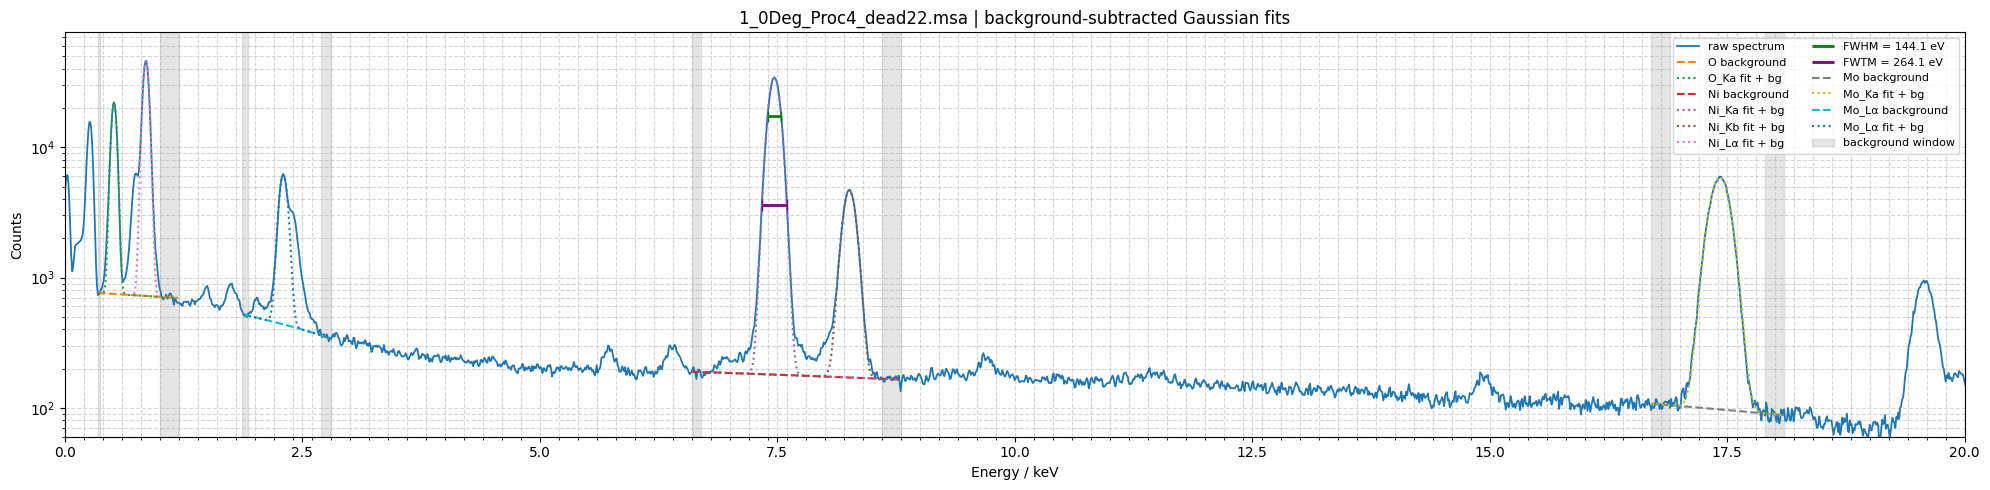

1_0Deg_Proc4_dead22.msa O_Ka=0.5189 keV, Ni_Ka=7.4710 keV, Ni_Kb=8.2601 keV, Ni_La=0.8553 keV, Mo_Ka=17.4224 keV, Mo_La=2.3021 keV, O_Ka=153421.1 Counts/Peak, Ni_Ka=525965.0 Counts/Peak, Ni_Kb=76103.9 Counts/Peak, Ni_La=359359.6 Counts/Peak, Mo_Ka=151198.5 Counts/Peak, Mo_La=63809.6 Counts/Peak


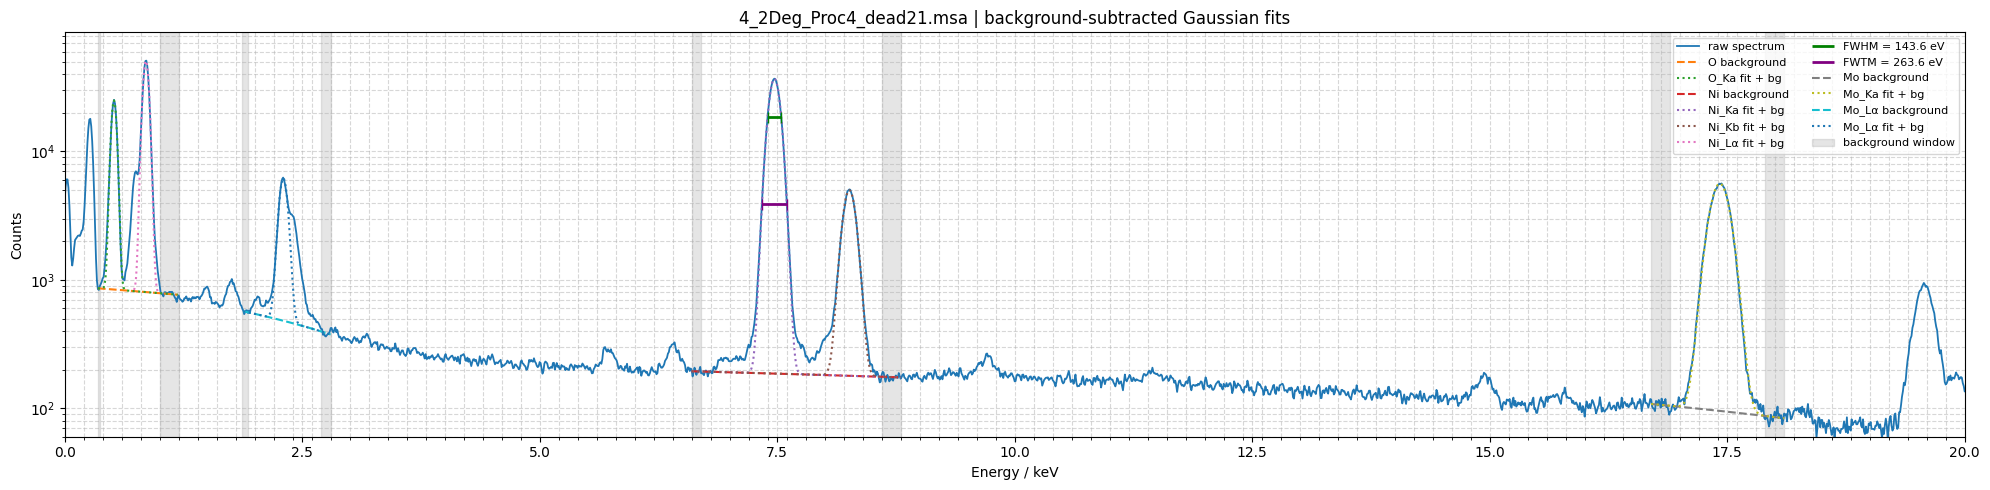

4_2Deg_Proc4_dead21.msa O_Ka=0.5190 keV, Ni_Ka=7.4711 keV, Ni_Kb=8.2600 keV, Ni_La=0.8554 keV, Mo_Ka=17.4224 keV, Mo_La=2.3020 keV, O_Ka=172399.4 Counts/Peak, Ni_Ka=562767.6 Counts/Peak, Ni_Kb=80981.4 Counts/Peak, Ni_La=395843.7 Counts/Peak, Mo_Ka=144151.5 Counts/Peak, Mo_La=63273.6 Counts/Peak


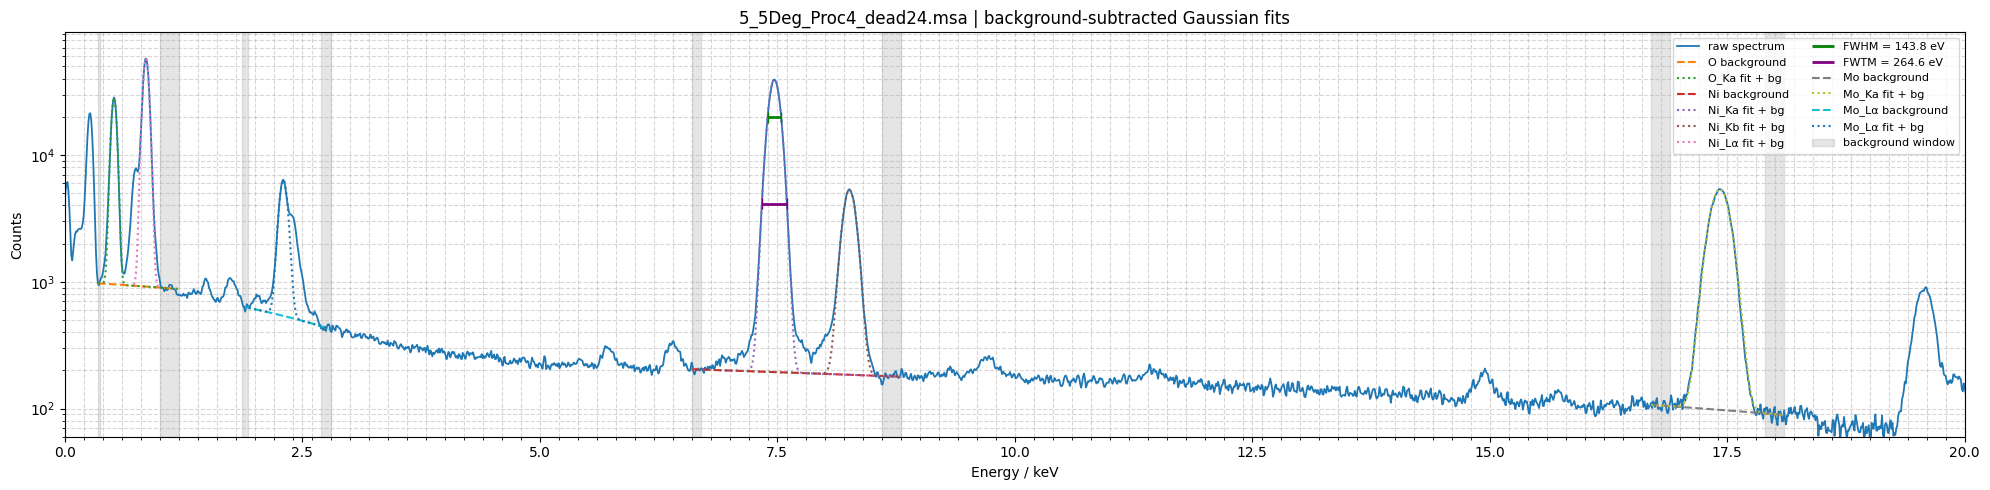

5_5Deg_Proc4_dead24.msa O_Ka=0.5192 keV, Ni_Ka=7.4710 keV, Ni_Kb=8.2608 keV, Ni_La=0.8555 keV, Mo_Ka=17.4230 keV, Mo_La=2.3022 keV, O_Ka=195006.8 Counts/Peak, Ni_Ka=600561.7 Counts/Peak, Ni_Kb=86473.7 Counts/Peak, Ni_La=448404.3 Counts/Peak, Mo_Ka=138041.4 Counts/Peak, Mo_La=63388.7 Counts/Peak


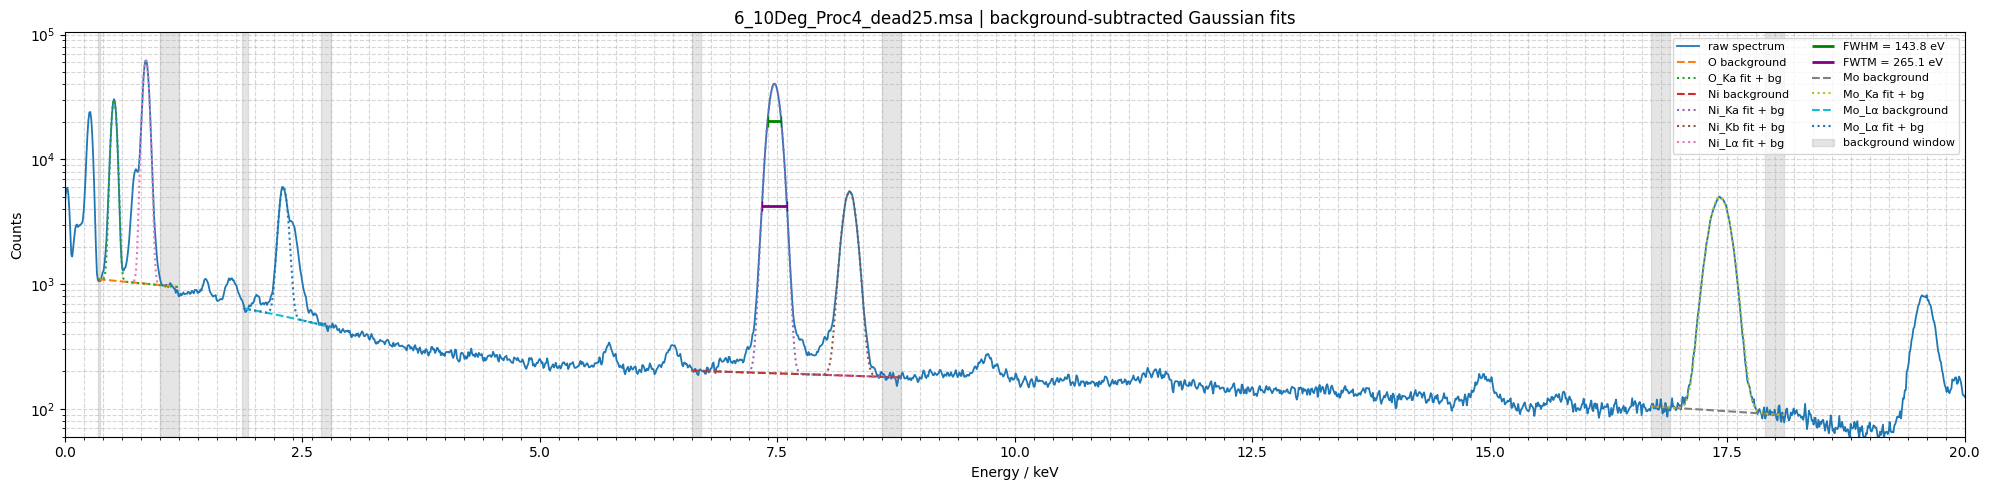

6_10Deg_Proc4_dead25.msa O_Ka=0.5192 keV, Ni_Ka=7.4710 keV, Ni_Kb=8.2615 keV, Ni_La=0.8554 keV, Mo_Ka=17.4230 keV, Mo_La=2.3022 keV, O_Ka=207204.3 Counts/Peak, Ni_Ka=619357.2 Counts/Peak, Ni_Kb=89385.5 Counts/Peak, Ni_La=483091.7 Counts/Peak, Mo_Ka=127457.6 Counts/Peak, Mo_La=60540.4 Counts/Peak


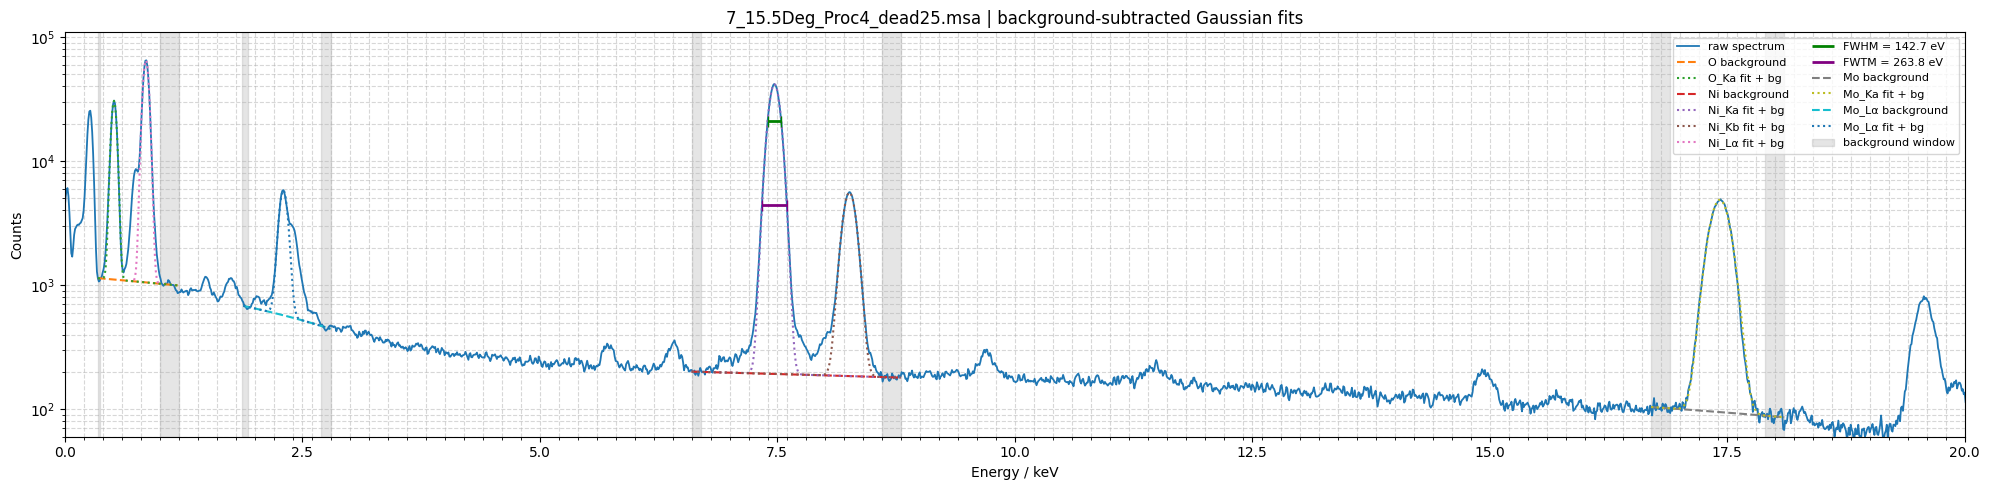

7_15.5Deg_Proc4_dead25.msa O_Ka=0.5192 keV, Ni_Ka=7.4711 keV, Ni_Kb=8.2606 keV, Ni_La=0.8554 keV, Mo_Ka=17.4229 keV, Mo_La=2.3022 keV, O_Ka=210198.1 Counts/Peak, Ni_Ka=635247.9 Counts/Peak, Ni_Kb=91822.4 Counts/Peak, Ni_La=505450.6 Counts/Peak, Mo_Ka=125619.6 Counts/Peak, Mo_La=57787.2 Counts/Peak


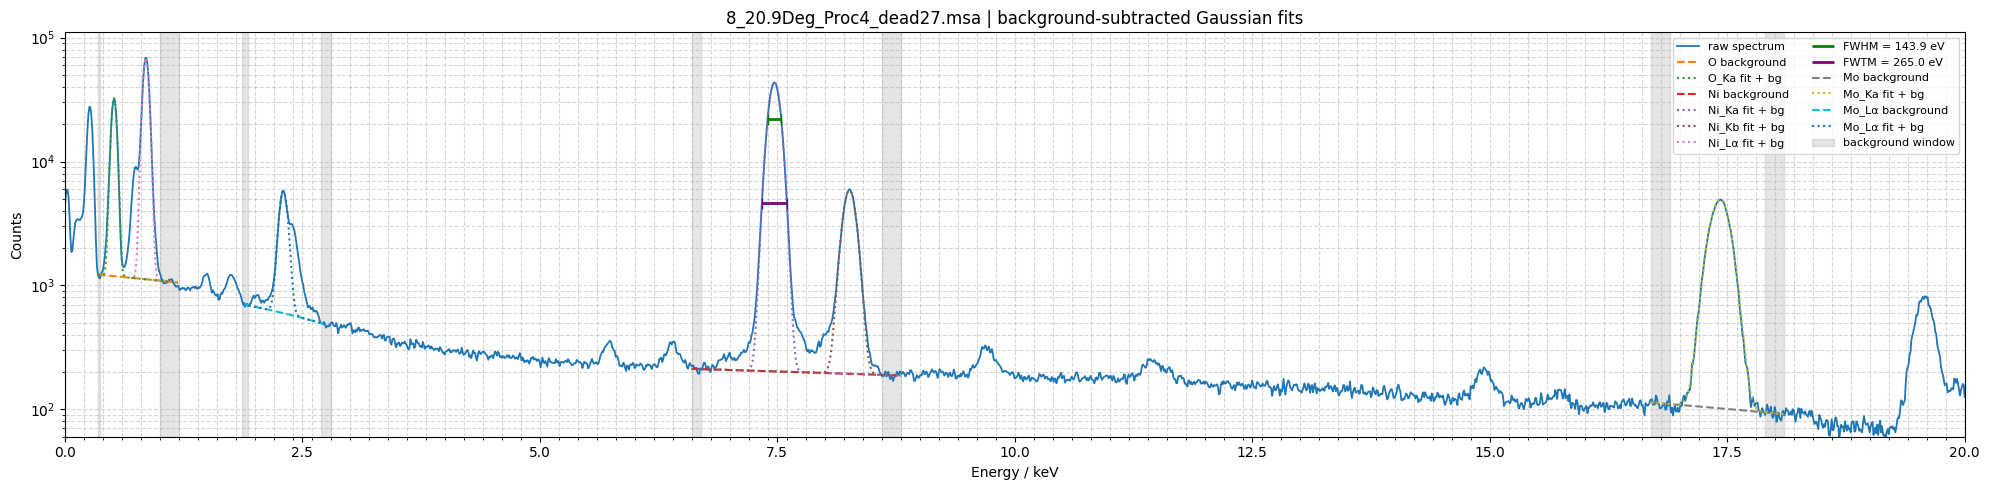

8_20.9Deg_Proc4_dead27.msa O_Ka=0.5193 keV, Ni_Ka=7.4710 keV, Ni_Kb=8.2608 keV, Ni_La=0.8555 keV, Mo_Ka=17.4226 keV, Mo_La=2.3024 keV, O_Ka=222133.6 Counts/Peak, Ni_Ka=667002.8 Counts/Peak, Ni_Kb=96327.2 Counts/Peak, Ni_La=535412.6 Counts/Peak, Mo_Ka=125859.4 Counts/Peak, Mo_La=56836.6 Counts/Peak


In [19]:
# ================================================================================================== Area of Gaussian ==================================================================================================

fit_results = []


def gauss(x, A, mu, sig):
    return A * np.exp(-(x - mu)**2 / (2 * sig**2))

def two_gauss(x, A1, mu1, sig1, A2, mu2, sig2):
    return gauss(x, A1, mu1, sig1) + gauss(x, A2, mu2, sig2)

def area_gauss(A, sig):
    return A * sig * np.sqrt(2 * np.pi)

def width_at_fraction(x, y, fraction):
    y0 = np.min(y)
    y = y - y0
    level = fraction * np.max(y)
    imax = np.argmax(y)

    left = np.where(y[:imax] < level)[0]
    right = np.where(y[imax:] < level)[0] + imax

    if len(left) == 0 or len(right) == 0:
        return np.nan, np.nan, np.nan, np.nan

    i1, i2 = left[-1], left[-1] + 1
    j2, j1 = right[0], right[0] - 1

    x_left = np.interp(level, [y[i1], y[i2]], [x[i1], x[i2]])
    x_right = np.interp(level, [y[j2], y[j1]], [x[j2], x[j1]])

    return x_right - x_left, x_left, x_right, level + y0


# ================================================================================================= Main loop over all spectra =================================================================================================

for f in files:

    # Load spectrum ================================================================================================================================================================================

    s = hs.load(f)
    s.set_signal_type("EDS_TEM")
    s.set_elements(["O", "Ni", "Mo"])
    s.set_lines(["O_Ka", "Ni_Ka", "Ni_Kb", "Ni_La", "Mo_Ka", "Mo_La"])

    x = s.axes_manager.signal_axes[0].axis
    y = s.data.astype(float)

    # Define fit ranges ================================================================================================================================================================================
   
    O_fit_min, O_fit_max = lmin_O, rmax_O
    Ni_fit_min, Ni_fit_max = lmin_Ni, rmax_Ni
    Ni_La_fit_min, Ni_La_fit_max = 0.80, 0.95
    Mo_fit_min, Mo_fit_max = lmin_Mo, rmax_Mo
    Mo_La_fit_min, Mo_La_fit_max = 2.2, 2.35

    # Create masks for fitting regions ================================================================================================================================================================================

    O_mask = (x >= O_fit_min) & (x <= O_fit_max)
    Ni_mask = (x >= Ni_fit_min) & (x <= Ni_fit_max)
    Ni_La_mask = (x >= Ni_La_fit_min) & (x <= Ni_La_fit_max)
    Mo_mask = (x >= Mo_fit_min) & (x <= Mo_fit_max)
    Mo_La_mask = (x >= Mo_La_fit_min) & (x <= Mo_La_fit_max)
    
    x_O, y_O = x[O_mask], y[O_mask]
    x_Ni, y_Ni = x[Ni_mask], y[Ni_mask]
    x_Ni_La, y_Ni_La = x[Ni_La_mask], y[Ni_La_mask]
    x_Mo, y_Mo = x[Mo_mask], y[Mo_mask]
    x_Mo_La, y_Mo_La = x[Mo_La_mask], y[Mo_La_mask]

    # Define background windows ================================================================================================================================================================================

    bg_mask_O = ((x >= lmin_O) & (x <= lmax_O)) | ((x >= rmin_O) & (x <= rmax_O))
    bg_mask_Ni = ((x >= lmin_Ni) & (x <= lmax_Ni)) | ((x >= rmin_Ni) & (x <= rmax_Ni))
    bg_mask_Ni_La = ((x >= lmin_O) & (x <= lmax_O)) | ((x >= rmin_O) & (x <= rmax_O))
    bg_mask_Mo = ((x >= lmin_Mo) & (x <= lmax_Mo)) | ((x >= rmin_Mo) & (x <= rmax_Mo))
    bg_mask_Mo_La = ((x >= lmin_Mo_La) & (x <= lmax_Mo_La)) | ((x >= rmin_Mo_La) & (x <= rmax_Mo_La))

    # Fit linear background ================================================================================================================================================================================

    p_O = np.polyfit(x[bg_mask_O], y[bg_mask_O], 1)
    p_Ni = np.polyfit(x[bg_mask_Ni], y[bg_mask_Ni], 1)
    p_Ni_La = np.polyfit(x[bg_mask_Ni_La], y[bg_mask_Ni_La], 1)
    p_Mo = np.polyfit(x[bg_mask_Mo], y[bg_mask_Mo], 1)
    p_Mo_La = np.polyfit(x[bg_mask_Mo_La], y[bg_mask_Mo_La], 1)

    bg_O = np.polyval(p_O, x_O)
    bg_Ni = np.polyval(p_Ni, x_Ni)
    bg_Ni_La = np.polyval(p_Ni_La, x_Ni_La)
    bg_Mo = np.polyval(p_Mo, x_Mo)
    bg_Mo_La = np.polyval(p_Mo_La, x_Mo_La)

    # Background subtraction ================================================================================================================================================================================

    y_O_sub = np.clip(y_O - bg_O, 0, None)
    y_Ni_sub = np.clip(y_Ni - bg_Ni, 0, None)
    y_Ni_La_sub = np.clip(y_Ni_La - bg_Ni_La, 0, None)
    y_Mo_sub = np.clip(y_Mo - bg_Mo, 0, None)
    y_Mo_La_sub = np.clip(y_Mo_La - bg_Mo_La, 0, None)

    # Gaussian fits ================================================================================================================================================================================

    # O Kα
    p0_O = [y_O_sub.max(), 0.525, 0.035]
    bounds_O = ([0, 0.45, 0.005], [np.inf, 0.60, 0.12])
    popt_O, _ = curve_fit(gauss, x_O, y_O_sub, p0=p0_O, bounds=bounds_O, maxfev=50000)
    A_O_Ka, mu_O_Ka, sig_O_Ka = popt_O

    # Mo Kα
    p0_Mo = [y_Mo_sub.max(), 17.42, 0.10]
    bounds_Mo = ([0, 17.20, 0.01], [np.inf, 17.60, 0.30])
    popt_Mo, _ = curve_fit(gauss, x_Mo, y_Mo_sub, p0=p0_Mo, bounds=bounds_Mo, maxfev=50000)
    A_Mo_Ka, mu_Mo_Ka, sig_Mo_Ka = popt_Mo

    # Mo Lα
    p0_Mo_La = [y_Mo_La_sub.max(), 2.29, 0.05]
    bounds_Mo_La = ([0, 2.20, 0.01], [np.inf, 2.40, 0.20])
    popt_Mo_La, _ = curve_fit(gauss, x_Mo_La, y_Mo_La_sub, p0=p0_Mo_La, bounds=bounds_Mo_La, maxfev=50000)
    A_Mo_La, mu_Mo_La, sig_Mo_La = popt_Mo_La
    
    # Ni Lα
    p0_Ni_La = [y_Ni_La_sub.max(), 0.85, 0.05]
    bounds_Ni_La = ([0, 0.80, 0.01], [np.inf, 0.95, 0.20])
    popt_Ni_La, _ = curve_fit(gauss, x_Ni_La, y_Ni_La_sub, p0=p0_Ni_La, bounds=bounds_Ni_La, maxfev=50000)
    A_Ni_La, mu_Ni_La, sig_Ni_La = popt_Ni_La

    # Ni Kα + Ni Kβ
    p0_Ni = [y_Ni_sub.max(), 7.47, 0.070, y_Ni_sub.max() * 0.8, 8.26, 0.070]
    bounds_Ni = ([0, 7.30, 0.01, 0, 8.05, 0.01], [np.inf, 7.65, 0.25, np.inf, 8.45, 0.25])
    popt_Ni, _ = curve_fit(two_gauss, x_Ni, y_Ni_sub, p0=p0_Ni, bounds=bounds_Ni, maxfev=50000)
    A_Ni_Ka, mu_Ni_Ka, sig_Ni_Ka, A_Ni_Kb, mu_Ni_Kb, sig_Ni_Kb = popt_Ni

    

    # Optional test: make Gaussian broader without affecting data-based FWHM/FWTM
    # sig_Ni_Ka *= 2

    # Data-based FWHM, FWTM and shape factor for Ni Kα

    Ni_Ka_mask = (x_Ni >= mu_Ni_Ka - 0.4) & (x_Ni <= mu_Ni_Ka + 0.4)
    x_Ni_Ka_only = x_Ni[Ni_Ka_mask]
    y_Ni_Ka_only = y_Ni_sub[Ni_Ka_mask]

    FWHM_Ni_Ka_data, x_FWHM_left, x_FWHM_right, y_FWHM_level = width_at_fraction(x_Ni_Ka_only, y_Ni_Ka_only, 0.5)
    FWTM_Ni_Ka_data, x_FWTM_left, x_FWTM_right, y_FWTM_level = width_at_fraction(x_Ni_Ka_only, y_Ni_Ka_only, 0.1)

    # Peak areas ================================================================================================================================================================================

    KeV_per_channel = 1 / s.axes_manager.signal_axes[0].scale

    area_O_Ka = area_gauss(A_O_Ka, sig_O_Ka) * KeV_per_channel
    area_Ni_Ka = area_gauss(A_Ni_Ka, sig_Ni_Ka) * KeV_per_channel
    area_Ni_Kb = area_gauss(A_Ni_Kb, sig_Ni_Kb) * KeV_per_channel
    area_Ni_La = area_gauss(A_Ni_La, sig_Ni_La) * KeV_per_channel
    area_Mo_Ka = area_gauss(A_Mo_Ka, sig_Mo_Ka) * KeV_per_channel
    area_Mo_La = area_gauss(A_Mo_La, sig_Mo_La) * KeV_per_channel

    # Store results ================================================================================================================================================================================

    fit_results.append({
        "file": f,
        "angle": extract_angle(f),

        "O_Ka_mu": mu_O_Ka,
        "Ni_Ka_mu": mu_Ni_Ka,
        "Ni_Kb_mu": mu_Ni_Kb,
        "Ni_La_mu": mu_Ni_La,
        "Mo_Ka_mu": mu_Mo_Ka,
        "Mo_La_mu": mu_Mo_La,

        "O_Ka_area": area_O_Ka,
        "Ni_Ka_area": area_Ni_Ka,
        "Ni_Kb_area": area_Ni_Kb,
        "Ni_La_area": area_Ni_La,
        "Mo_Ka_area": area_Mo_Ka,
        "Mo_La_area": area_Mo_La,

        "O_background_windows": (lmin_O, lmax_O, rmin_O, rmax_O),
        "Ni_background_windows": (lmin_Ni, lmax_Ni, rmin_Ni, rmax_Ni),
        "Mo_background_windows": (lmin_Mo, lmax_Mo, rmin_Mo, rmax_Mo),
        "Mo_La_background_windows": (lmin_Mo_La, lmax_Mo_La, rmin_Mo_La, rmax_Mo_La),

        "O_background_poly": p_O,
        "Ni_background_poly": p_Ni,
        "Ni_La_background_poly": p_Ni_La,
        "Mo_background_poly": p_Mo,
        "Mo_La_background_poly": p_Mo_La,

        "O_Ka_sig": sig_O_Ka,
        "Ni_Ka_sig": sig_Ni_Ka,
        "Ni_Kb_sig": sig_Ni_Kb,
        "Ni_La_sig": sig_Ni_La,
        "Mo_Ka_sig": sig_Mo_Ka,
        "Mo_La_sig": sig_Mo_La,

        "Ni_Ka_FWHM_data": FWHM_Ni_Ka_data,
        "Ni_Ka_FWTM_data": FWTM_Ni_Ka_data,
    })

    # ----------------------------------------------------------------------------------------------
    # Plot spectrum, background and Gaussian fits
    # ----------------------------------------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(20, 5))
    ax.plot(x, y, label="raw spectrum", linewidth=1.3)

    # O Kα plot
    xO_plot = x[(x >= lmin_O) & (x <= rmax_O)]
    bgO_plot = np.polyval(p_O, xO_plot)
    O_Ka_plot = gauss(xO_plot, A_O_Ka, mu_O_Ka, sig_O_Ka)

    ax.plot(xO_plot, bgO_plot, "--", label="O background")
    ax.plot(xO_plot, bgO_plot + O_Ka_plot, ":", label="O_Ka fit + bg")

    # Ni Kα / Kβ plot
    xNi_plot = x[(x >= lmin_Ni) & (x <= rmax_Ni)]
    bgNi_plot = np.polyval(p_Ni, xNi_plot)
    Ni_Ka_plot = gauss(xNi_plot, A_Ni_Ka, mu_Ni_Ka, sig_Ni_Ka)
    Ni_Kb_plot = gauss(xNi_plot, A_Ni_Kb, mu_Ni_Kb, sig_Ni_Kb)

    ax.plot(xNi_plot, bgNi_plot, "--", label="Ni background")
    ax.plot(xNi_plot, bgNi_plot + Ni_Ka_plot, ":", label="Ni_Ka fit + bg")
    ax.plot(xNi_plot, bgNi_plot + Ni_Kb_plot, ":", label="Ni_Kb fit + bg")

    # Ni Lα plot
    xNi_La_plot = x[(x >= 0.73) & (x <= 1.00)]
    bgNi_La_plot = np.polyval(p_Ni_La, xNi_La_plot)
    Ni_La_plot = gauss(xNi_La_plot, A_Ni_La, mu_Ni_La, sig_Ni_La)

    # ax.plot(xNi_La_plot, bgNi_La_plot, "--", label="Ni_Lα background")
    ax.plot(xNi_La_plot, bgNi_La_plot + Ni_La_plot, ":", label="Ni_Lα fit + bg")

    # FWHM / FWTM markers for Ni Kα
    y_FWHM_plot = np.polyval(p_Ni, (x_FWHM_left + x_FWHM_right) / 2) + y_FWHM_level
    y_FWTM_plot = np.polyval(p_Ni, (x_FWTM_left + x_FWTM_right) / 2) + y_FWTM_level

    ax.hlines(y_FWHM_plot, x_FWHM_left, x_FWHM_right, color="green", linewidth=2, label=f"FWHM = {FWHM_Ni_Ka_data*1000:.1f} eV")
    ax.hlines(y_FWTM_plot, x_FWTM_left, x_FWTM_right, color="purple", linewidth=2, label=f"FWTM = {FWTM_Ni_Ka_data*1000:.1f} eV")
    ax.vlines([x_FWHM_left, x_FWHM_right], y_FWHM_plot*0.9, y_FWHM_plot*1.1, color="green", linewidth=1)
    ax.vlines([x_FWTM_left, x_FWTM_right], y_FWTM_plot*0.9, y_FWTM_plot*1.1, color="purple", linewidth=1)

    # Mo Kα plot
    xMo_plot = x[(x >= lmin_Mo) & (x <= rmax_Mo)]
    bgMo_plot = np.polyval(p_Mo, xMo_plot)
    Mo_Ka_plot = gauss(xMo_plot, A_Mo_Ka, mu_Mo_Ka, sig_Mo_Ka)

    ax.plot(xMo_plot, bgMo_plot, "--", label="Mo background")
    ax.plot(xMo_plot, bgMo_plot + Mo_Ka_plot, ":", label="Mo_Ka fit + bg")

    # Mo Lα plot
    xMo_La_plot = x[(x >= lmin_Mo_La) & (x <= rmax_Mo_La)]
    bgMo_La_plot = np.polyval(p_Mo_La, xMo_La_plot)
    Mo_La_plot = gauss(xMo_La_plot, A_Mo_La, mu_Mo_La, sig_Mo_La)

    ax.plot(xMo_La_plot, bgMo_La_plot, "--", label="Mo_Lα background")
    ax.plot(xMo_La_plot, bgMo_La_plot + Mo_La_plot, ":", label="Mo_Lα fit + bg")

    # Background windows
    ax.axvspan(lmin_O, lmax_O, color="grey", alpha=0.2, label="background window")
    ax.axvspan(rmin_O, rmax_O, color="grey", alpha=0.2)
    ax.axvspan(lmin_Ni, lmax_Ni, color="grey", alpha=0.2)
    ax.axvspan(rmin_Ni, rmax_Ni, color="grey", alpha=0.2)
    ax.axvspan(lmin_Mo, lmax_Mo, color="grey", alpha=0.2)
    ax.axvspan(rmin_Mo, rmax_Mo, color="grey", alpha=0.2)
    ax.axvspan(lmin_Mo_La, lmax_Mo_La, color="grey", alpha=0.2)
    ax.axvspan(rmin_Mo_La, rmax_Mo_La, color="grey", alpha=0.2)
    # ax.axvline(x_Ni_bg_left, color="black", linestyle="--", label="Ni background window")  
    # ax.axvline(x_Ni_bg_right, color="black", linestyle="--")    

    # Plot style
    ax.set_xlabel("Energy / keV")
    ax.set_ylabel("Counts")
    ax.set_title(f"{f.name} | background-subtracted Gaussian fits")
    ax.set_yscale("log")
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.set_xlim(0, 20)
    ax.set_ylim(bottom=60)
    ax.legend(ncol=2, fontsize=8)

    plt.tight_layout()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

    # Print result summary

    print(
        f"{f.name:15} "
        f"O_Ka={mu_O_Ka:.4f} keV, "
        f"Ni_Ka={mu_Ni_Ka:.4f} keV, "
        f"Ni_Kb={mu_Ni_Kb:.4f} keV, "
        f"Ni_La={mu_Ni_La:.4f} keV, "
        f"Mo_Ka={mu_Mo_Ka:.4f} keV, "
        f"Mo_La={mu_Mo_La:.4f} keV, "
        f"O_Ka={area_O_Ka:.1f} Counts/Peak, "
        f"Ni_Ka={area_Ni_Ka:.1f} Counts/Peak, "
        f"Ni_Kb={area_Ni_Kb:.1f} Counts/Peak, "
        f"Ni_La={area_Ni_La:.1f} Counts/Peak, "
        f"Mo_Ka={area_Mo_Ka:.1f} Counts/Peak, "
        f"Mo_La={area_Mo_La:.1f} Counts/Peak"
    )

<center>

# Calibration of Scale & Offset 
</center>

Following the Spectrum will be Calibarated with the The Gallium  L-alpha and the K-alpha peak. 
First the first peak will be shifted to the expected spot. That the Energy of L-alpha peak matches the Literature values. Then the bin width, which is before 2eV will be adjusted that also K-alpha peak matches the Literature values. Afterwards the new Offset value and the new Binwidth will be printed.

Idealy the claibration will be done with the a calibration Sample like NiO. The peaks should idealy be spread far from each other and be relativly isolated. 

In [13]:
# ================================================================================================== Calibration of Y-Scale =================================================================================================================

calibrated_spectra = []

#Energy calibration using the measured peak positions of O_Ka and Mo_Ka, which are well-known reference lines in EDS spectra. We will apply a linear calibration to adjust the energy scale of each spectrum so that the measured peak positions match the true energies of these lines.
E_O_Ka_true = s._get_line_energy("O_Ka")
E_Mo_Ka_true = s._get_line_energy("Mo_Ka")
print(f"Amount of Channels: {s.axes_manager.signal_axes[0].size}, Channel Width: {s.axes_manager.signal_axes[0].scale:.6f} keV/channel")

for fit in fit_results:
    f = fit["file"]

    s = hs.load(f)
    s.set_signal_type("EDS_TEM")

    ax = s.axes_manager.signal_axes[0]

    # measured peak positions from Gaussian fits
    E_O_Ka_meas = fit["O_Ka_mu"]
    E_Mo_Ka_meas = fit["Mo_Ka_mu"]

    # linear calibration: E_true = a * E_meas + b
    a = (E_Mo_Ka_true - E_O_Ka_true) / (E_Mo_Ka_meas - E_O_Ka_meas)
    b = E_O_Ka_true - a * E_O_Ka_meas

    old_scale = ax.scale
    old_offset = ax.offset
    ax.scale = old_scale * a
    ax.offset = a * old_offset + b

    calibrated_spectra.append((f, s))

    print(f"{f.name:12}  " f"O_Ka_meas={E_O_Ka_meas:.4f} keV, " f"Mo_Ka_meas={E_Mo_Ka_meas:.4f} keV   " f"new bin_width={ax.scale:.6f} keV/bin, " f"new offset={ax.offset:.6f} keV")

Amount of Channels: 2048, Channel Width: 0.010000 keV/channel
14_-20.0Deg_Proc4_dead11.msa  O_Ka_meas=0.5244 keV, Mo_Ka_meas=17.4232 keV   new bin_width=0.010033 keV/bin, new offset=-0.201921 keV
13_-15.0Deg_Proc4_dead12.msa  O_Ka_meas=0.5192 keV, Mo_Ka_meas=17.4225 keV   new bin_width=0.010030 keV/bin, new offset=-0.196472 keV
11_-10.0Deg_Proc4_dead14.msa  O_Ka_meas=0.5188 keV, Mo_Ka_meas=17.4225 keV   new bin_width=0.010030 keV/bin, new offset=-0.196010 keV
10_-5.0Deg_Proc4_dead18.msa  O_Ka_meas=0.5188 keV, Mo_Ka_meas=17.4227 keV   new bin_width=0.010030 keV/bin, new offset=-0.196022 keV
9_-1.8Deg_Proc4_dead20.msa  O_Ka_meas=0.5190 keV, Mo_Ka_meas=17.4224 keV   new bin_width=0.010030 keV/bin, new offset=-0.196297 keV
1_0Deg_Proc4_dead22.msa  O_Ka_meas=0.5189 keV, Mo_Ka_meas=17.4224 keV   new bin_width=0.010030 keV/bin, new offset=-0.196181 keV
4_2Deg_Proc4_dead21.msa  O_Ka_meas=0.5190 keV, Mo_Ka_meas=17.4224 keV   new bin_width=0.010030 keV/bin, new offset=-0.196306 keV
5_5Deg_Proc4_

$$
\frac{C_{\mathrm{O}}}{C_{\mathrm{N}}} = k_{\mathrm{O/Ni}} \cdot \frac{A_{\mathrm{O}}}{A_{\mathrm{Ni}}}
$$
With C as the Composition and A as Area below the peak But this this the weighted composition not the Atomic composition 
$$
k_{\mathrm{O/Ni}}=\frac{k_{\mathrm{O/Si}}}{k_{\mathrm{Ni/Si}}} \cdot CalibrationFactor
$$
For Atomic Composition you need to multiply the inversed Mass ratio
$$
CalibrationFactor \approx \frac{Atomic Mass Nickl}{Atomic Mass Oxigen}=\frac{58.70}{16.00}=3.66875
$$
But the calibration will be slightly adapted in that way that the coomposition  averages about

<center>

# Quantification or k-factor dependence of the Holder X-Tilt
</center>

k_(O_Ka/Ni_Ka) = 2.085 , k_(Ni_Ka/O_Ka) = 1.27 , k_(O_Ka/Ni_Ka)_Calibrated = 6.02310531496063

14_-20.0Deg_Proc4_dead11.msa  Ni_Composition: 62.05 at.%, O_Composition: 37.95 at.%   Ni_Ka_Area=46370.6, O_Ka_Area=4707.9, O_Ka/Ni_Ka=0.102
13_-15.0Deg_Proc4_dead12.msa  Ni_Composition: 42.96 at.%, O_Composition: 57.04 at.%   Ni_Ka_Area=156416.0, O_Ka_Area=34477.2, O_Ka/Ni_Ka=0.220
11_-10.0Deg_Proc4_dead14.msa  Ni_Composition: 38.79 at.%, O_Composition: 61.21 at.%   Ni_Ka_Area=282588.4, O_Ka_Area=74021.5, O_Ka/Ni_Ka=0.262
10_-5.0Deg_Proc4_dead18.msa  Ni_Composition: 37.01 at.%, O_Composition: 62.99 at.%   Ni_Ka_Area=413282.5, O_Ka_Area=116806.9, O_Ka/Ni_Ka=0.283
9_-1.8Deg_Proc4_dead20.msa  Ni_Composition: 36.43 at.%, O_Composition: 63.57 at.%   Ni_Ka_Area=489786.8, O_Ka_Area=141915.6, O_Ka/Ni_Ka=0.290
1_0Deg_Proc4_dead22.msa  Ni_Composition: 36.27 at.%, O_Composition: 63.73 at.%   Ni_Ka_Area=525965.0, O_Ka_Area=153421.1, O_Ka/Ni_Ka=0.292
4_2Deg_Proc4_dead21.msa  Ni_Composition: 35.15 at.%, O

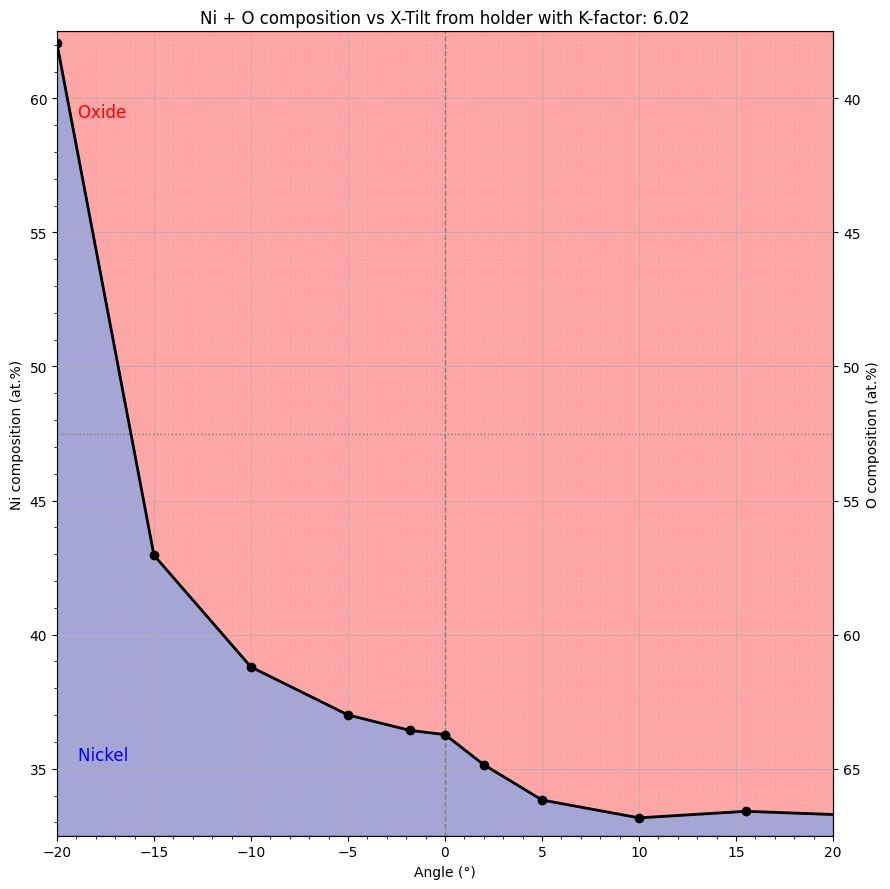

In [ ]:
# ================================================================================================== Quantification with k-factors & Composition Plot =================================================================================================================

results = []

# #reload only if you update the k_factors, otherwise you can just import it once at the top of the notebook
# import importlib
# import organized.k_factors as kf_module
# importlib.reload(kf_module)
# k_factors = kf_module.k_factors

# HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE

Calibration_Factor =3.66875 # Mass ratio of Ni and O 58.70/16.00 = 3.66875

# HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE 

k_ONi= (k_factors["O_Ka"] / k_factors["Ni_Ka"]) * Calibration_Factor


print("k_(O_Ka/Ni_Ka) =", k_factors["O_Ka"], ", k_(Ni_Ka/O_Ka) =", k_factors["Ni_Ka"], ", k_(O_Ka/Ni_Ka)_Calibrated =", k_ONi)
print()

# calculate composition for each fit result

for fit in fit_results:
    area_ni = fit["Ni_Ka_area"]
    area_o = fit["O_Ka_area"]

    Ni_Composition = 1
    O_Composition = k_ONi * (area_o / area_ni) * Ni_Composition

    Ni_comp_final = Ni_Composition / (Ni_Composition + O_Composition) * 100
    O_comp_final = O_Composition / (Ni_Composition + O_Composition) * 100
    

    results.append({
        "file": fit["file"].name,
        "angle": fit["angle"],
        "Ni_Ka": area_ni,
        "O_Ka": area_o,
        "Ni_comp": Ni_comp_final,
        "O_comp": O_comp_final,
    })

    print(
        f"{fit['file'].name:10}  "
        f"Ni_Composition: {Ni_comp_final:.2f} at.%, "
        f"O_Composition: {O_comp_final:.2f} at.%   "
        f"Ni_Ka_Area={area_ni:.1f}, "
        f"O_Ka_Area={area_o:.1f}, "
        f"O_Ka/Ni_Ka={area_o/area_ni:.3f}"
    )

ni_avg = np.mean([r["Ni_comp"] for r in results])
o_avg = np.mean([r["O_comp"] for r in results])
ni_area_avg = np.mean([r["Ni_Ka"] for r in results])
o_area_avg = np.mean([r["O_Ka"] for r in results])

print()
print(
    f"{'AVERAGE':10}  "
    f"Ni_Composition: {ni_avg:.2f} at.%, "
    f"O_Composition: {o_avg:.2f} at.%   "
    f"Ni_Ka_Area={ni_area_avg:.1f}, "
    f"O_Ka_Area={o_area_avg:.1f}, "
    f"O_Ka/Ni_Ka={o_area_avg/ni_area_avg:.3f}"
)

# ================================================================================================== Angle Dependence Composition Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results = sorted(results, key=lambda r: r["angle"])

angles = [r["angle"] for r in results]
ga = [r["Ni_comp"] for r in results]

fig, ax1 = plt.subplots(figsize=(9, 9))

center = 47.5
CenteringRange = 15
ymin = center - CenteringRange
ymax = center + CenteringRange


ax1.set_ylim(ymin, ymax)
ax1.set_xlim(-20, 20)

ymin, ymax = ax1.get_ylim()

# fill ABOVE the curve
ax1.fill_between(angles, ga, ymax, color="red", alpha=0.35)

# fill BELOW the curve
ax1.fill_between(angles, ga, ymin, color="darkblue", alpha=0.35)

# main curve
ax1.plot(angles, ga, marker="o", linewidth=2, color="black", zorder=3)

# axes and labels
ax1.set_xlabel("Angle (°)")
ax1.set_ylabel("Ni composition (at.%)")
ax1.set_title(f"Ni + O composition vs X-Tilt from holder with K-factor: {k_ONi:.2f}")

# grid
ax1.minorticks_on()
ax1.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax1.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)

# symmetry and center line
ax1.axvline(0, color="grey", linestyle="--", linewidth=1)
ax1.axhline(center, color="grey", linestyle=":", linewidth=1)

# right axis = As = 100 - Ga
secax = ax1.secondary_yaxis(
    'right',
    functions=(lambda y: 100 - y, lambda y: 100 - y)
)
secax.set_ylabel("O composition (at.%)")

# labels
ax1.text(min(angles), center + 4*CenteringRange/5, "    Oxide", fontsize=12, color="red", va="center")
ax1.text(min(angles), center - 4*CenteringRange/5, "    Nickel", fontsize=12, color="blue", va="center")

plt.tight_layout()
# plt.savefig(PlotPath / f"CompositionVsAngle_{timestamp}.pdf") # uncomment to save Vectrographics with timestamp
plt.show()

k_(O_Ka/Ni_Ka) = 2.085 , k_(Ni_Ka/O_Ka) = 1.27 , k_(O_Ka/Ni_Ka)_Calibrated = 6.02310531496063

14_-20.0Deg_Proc4_dead11.msa  Ni_Ka_Area=46370.6, O_Ka_Area=4707.9, O_Ka/Ni_Ka=0.102, k_ONi=9.8496
13_-15.0Deg_Proc4_dead12.msa  Ni_Ka_Area=156416.0, O_Ka_Area=34477.2, O_Ka/Ni_Ka=0.220, k_ONi=4.5368
11_-10.0Deg_Proc4_dead14.msa  Ni_Ka_Area=282588.4, O_Ka_Area=74021.5, O_Ka/Ni_Ka=0.262, k_ONi=3.8177
10_-5.0Deg_Proc4_dead18.msa  Ni_Ka_Area=413282.5, O_Ka_Area=116806.9, O_Ka/Ni_Ka=0.283, k_ONi=3.5382
9_-1.8Deg_Proc4_dead20.msa  Ni_Ka_Area=489786.8, O_Ka_Area=141915.6, O_Ka/Ni_Ka=0.290, k_ONi=3.4513
1_0Deg_Proc4_dead22.msa  Ni_Ka_Area=525965.0, O_Ka_Area=153421.1, O_Ka/Ni_Ka=0.292, k_ONi=3.4282
4_2Deg_Proc4_dead21.msa  Ni_Ka_Area=562767.6, O_Ka_Area=172399.4, O_Ka/Ni_Ka=0.306, k_ONi=3.2643
5_5Deg_Proc4_dead24.msa  Ni_Ka_Area=600561.7, O_Ka_Area=195006.8, O_Ka/Ni_Ka=0.325, k_ONi=3.0797
6_10Deg_Proc4_dead25.msa  Ni_Ka_Area=619357.2, O_Ka_Area=207204.3, O_Ka/Ni_Ka=0.335, k_ONi=2.9891
7_15.5Deg_Proc

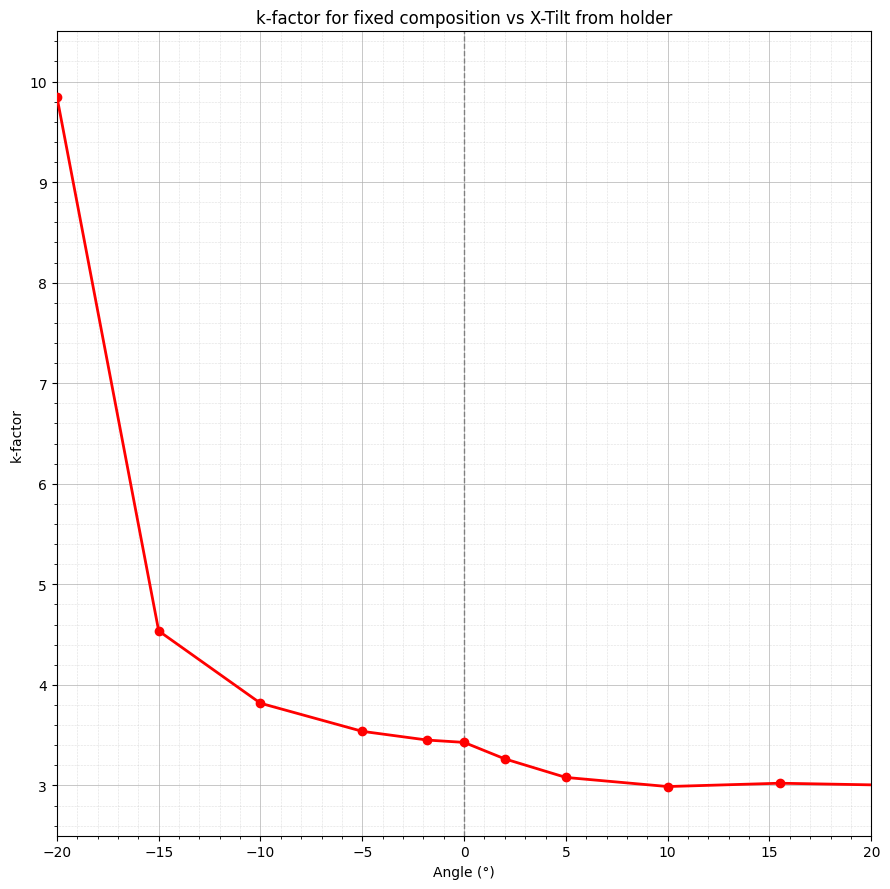

In [ ]:
# ================================================================================================== k-factor Calculation with Plot =================================================================================================================

results = []

# HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE

Calibration_Factor = 3.66875 # Mass ratio of Ni and O 58.70/16.00 = 3.66875

# HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE HERE 

k_ONi_theory = (k_factors["O_Ka"] / k_factors["Ni_Ka"]) * Calibration_Factor

print("k_(O_Ka/Ni_Ka) =", k_factors["O_Ka"], ", k_(Ni_Ka/O_Ka) =", k_factors["Ni_Ka"], ", k_(O_Ka/Ni_Ka)_Calibrated =", k_ONi_theory)
print()

# fixed composition
Ni_Composition = 50
O_Composition = 50

# calculate k-factor for each fit result

for fit in fit_results:
    area_ni = fit["Ni_Ka_area"]
    area_o = fit["O_Ka_area"]

    # because Ni/O composition is fixed to 50/50:
    # O/Ni = 1 = k_ONi * (O_Ka/Ni_Ka)
    k_ONi = area_ni / area_o

    results.append({
        "file": fit["file"].name,
        "angle": fit["angle"],
        "Ni_Ka": area_ni,
        "O_Ka": area_o,
        "Ni_comp": Ni_Composition,
        "O_comp": O_Composition,
        "k_ONi": k_ONi,
    })

    print(
        f"{fit['file'].name:10}  "
        f"Ni_Ka_Area={area_ni:.1f}, "
        f"O_Ka_Area={area_o:.1f}, "
        f"O_Ka/Ni_Ka={area_o/area_ni:.3f}, "
        f"k_ONi={k_ONi:.4f}"
    )


ni_area_avg = np.mean([r["Ni_Ka"] for r in results])
o_area_avg = np.mean([r["O_Ka"] for r in results])
k_ONi_avg = np.mean([r["k_ONi"] for r in results])

print()
print(
    f"{'AVERAGE':10}  "

    f"Ni_Ka_Area={ni_area_avg:.1f}, "
    f"O_Ka_Area={o_area_avg:.1f}, "
    f"O_Ka/Ni_Ka={o_area_avg/ni_area_avg:.3f}, "
    f"k_ONi_avg={k_ONi_avg:.4f}"
)# ================================================================================================== Angle Dependence k-Factor Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results = sorted(results, key=lambda r: r["angle"])

angles = [r["angle"] for r in results]
k_values = [r["k_ONi"] for r in results]

fig, ax1 = plt.subplots(figsize=(9, 9))

center = 6.5
CenteringRange = 4
ymin = center - CenteringRange
ymax = center + CenteringRange

ax1.set_ylim(ymin, ymax)
ax1.set_xlim(-20, 20)

ymin, ymax = ax1.get_ylim()


ax1.plot(angles, k_values, marker="o", linewidth=2, color="red", zorder=3)

ax1.set_xlabel("Angle (°)")
ax1.set_ylabel("k-factor")
ax1.set_title(f"k-factor for fixed composition vs X-Tilt from holder")

ax1.minorticks_on()
ax1.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax1.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)

ax1.axvline(0, color="grey", linestyle="--", linewidth=1)






plt.tight_layout()
# plt.savefig(PlotPath / f"kFactorVsAngle_{timestamp}.pdf") # uncomment to save Vectrographics with timestamp
plt.show()

<center>

# Energy Resolution

</center>

$$\triangle(Mn) \approx 0.926 FWHM(Ni_{K\alpha})$$

The detectors ability to distinguish different X-ray lines from each other. Typical value is 130 eV.

Angle = -20.00°   FWHM(Ni_Ka) = 144.9718 eV   Mn Kα-equivalent resolution = 134.2439 eV
Angle = -15.00°   FWHM(Ni_Ka) = 144.4492 eV   Mn Kα-equivalent resolution = 133.7600 eV
Angle = -10.00°   FWHM(Ni_Ka) = 144.2871 eV   Mn Kα-equivalent resolution = 133.6099 eV
Angle =  -5.00°   FWHM(Ni_Ka) = 144.1035 eV   Mn Kα-equivalent resolution = 133.4398 eV
Angle =  -1.80°   FWHM(Ni_Ka) = 144.6862 eV   Mn Kα-equivalent resolution = 133.9794 eV
Angle =   0.00°   FWHM(Ni_Ka) = 144.4991 eV   Mn Kα-equivalent resolution = 133.8062 eV
Angle =   2.00°   FWHM(Ni_Ka) = 144.4804 eV   Mn Kα-equivalent resolution = 133.7888 eV
Angle =   5.00°   FWHM(Ni_Ka) = 144.3923 eV   Mn Kα-equivalent resolution = 133.7073 eV
Angle =  10.00°   FWHM(Ni_Ka) = 144.7932 eV   Mn Kα-equivalent resolution = 134.0785 eV
Angle =  15.50°   FWHM(Ni_Ka) = 144.1245 eV   Mn Kα-equivalent resolution = 133.4593 eV
Angle =  20.90°   FWHM(Ni_Ka) = 144.7751 eV   Mn Kα-equivalent resolution = 134.0618 eV

Average Mn Kα-equivalent resolu

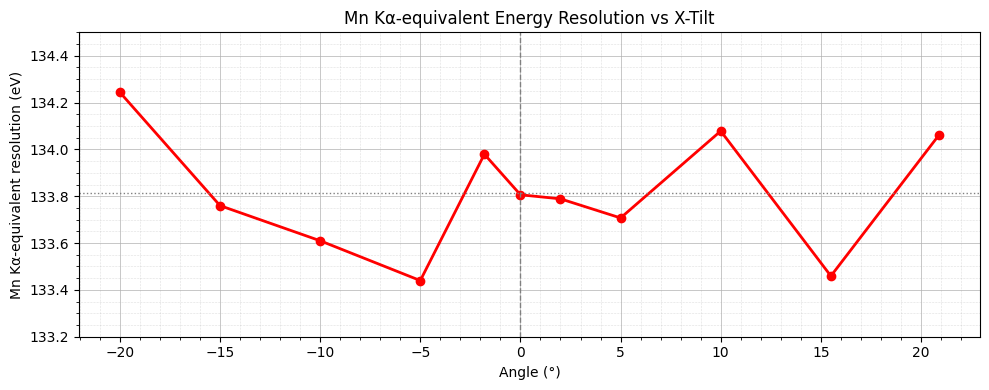

In [18]:
# ================================================================================================== Energy Resolution Plot =================================================================================================================

results_resolution = []

for fit in fit_results:
    angle = fit["angle"]
    sig_Ni_Ka = fit["Ni_Ka_sig"]

    FWHM_Ni_Ka = 2 * np.sqrt(2*np.log(2)) * sig_Ni_Ka
    Mn_equivalent_resolution = 0.926 * FWHM_Ni_Ka

    results_resolution.append({"angle": angle, "FWHM_Ni_Ka": FWHM_Ni_Ka, "Mn_equivalent_resolution": Mn_equivalent_resolution})

    print(f"Angle = {angle:6.2f}°   " f"FWHM(Ni_Ka) = {FWHM_Ni_Ka*1000:.4f} eV   " f"Mn Kα-equivalent resolution = {Mn_equivalent_resolution*1000:.4f} eV")

mn_avg = np.mean([r["Mn_equivalent_resolution"] for r in results_resolution])

print()
print(f"Average Mn Kα-equivalent resolution = {mn_avg * 1000:.1f} eV")


# ================================================================================================== Energy Resolution vs Angle Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results_resolution = sorted(results_resolution, key=lambda r: r["angle"])

angles = np.array([r["angle"] for r in results_resolution])
mn_resolution = np.array([r["Mn_equivalent_resolution"] for r in results_resolution])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(angles, mn_resolution * 1000, marker="o", linewidth=2, color="red")
ax.set_xlabel("Angle (°)")
ax.set_ylabel("Mn Kα-equivalent resolution (eV)")
ax.set_ylim(133.2, 134.5)
ax.set_title("Mn Kα-equivalent Energy Resolution vs X-Tilt")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.axhline(mn_avg*1000, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
# plt.savefig(PlotPath / f"MnResolutionVsAngle_{timestamp}.pdf") # uncomment to save Vectrographics with timestamp
plt.show()

<center>

# Peak Shape

</center>

$$ S=\frac{FWTM(Ni_{K\alpha})}{FWHM(Ni_{K\alpha})} $$
For a perfect Gaussian peak:
$$S_{Gaussien}=\sqrt{\frac{ln(10)}{ln(2)}}\approx 1.823$$


  Values > 2.0 may indicate peak tailing, due to incomplete charge collection.

Angle = -20.00°   FWHM(Ni_Ka) = 145.7772 eV   FWTM(Ni_Ka) = 268.6374 eV   Shape factor (S) = 1.843
Angle = -15.00°   FWHM(Ni_Ka) = 143.0239 eV   FWTM(Ni_Ka) = 262.1403 eV   Shape factor (S) = 1.833
Angle = -10.00°   FWHM(Ni_Ka) = 144.2500 eV   FWTM(Ni_Ka) = 265.6526 eV   Shape factor (S) = 1.842
Angle =  -5.00°   FWHM(Ni_Ka) = 143.6169 eV   FWTM(Ni_Ka) = 263.0655 eV   Shape factor (S) = 1.832
Angle =  -1.80°   FWHM(Ni_Ka) = 145.1733 eV   FWTM(Ni_Ka) = 264.0927 eV   Shape factor (S) = 1.819
Angle =   0.00°   FWHM(Ni_Ka) = 144.0801 eV   FWTM(Ni_Ka) = 264.0537 eV   Shape factor (S) = 1.833
Angle =   2.00°   FWHM(Ni_Ka) = 143.6037 eV   FWTM(Ni_Ka) = 263.6457 eV   Shape factor (S) = 1.836
Angle =   5.00°   FWHM(Ni_Ka) = 143.8488 eV   FWTM(Ni_Ka) = 264.5549 eV   Shape factor (S) = 1.839
Angle =  10.00°   FWHM(Ni_Ka) = 143.7562 eV   FWTM(Ni_Ka) = 265.1119 eV   Shape factor (S) = 1.844
Angle =  15.50°   FWHM(Ni_Ka) = 142.6977 eV   FWTM(Ni_Ka) = 263.8393 eV   Shape factor (S) = 1.849
Angle =  2

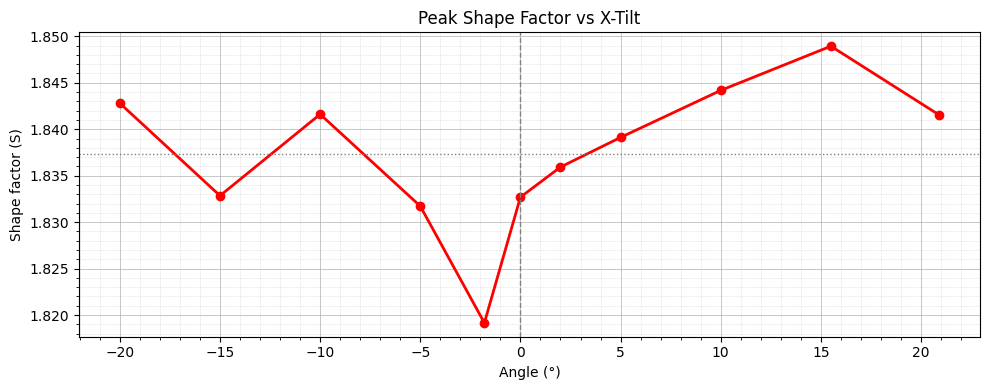

In [ ]:
# ================================================================================================== Peak Shape Factor Plot =================================================================================================================

results_shape = []

for fit in fit_results:
    angle = fit["angle"]
    FWHM_Ni_Ka = fit["Ni_Ka_FWHM_data"]
    FWTM_Ni_Ka = fit["Ni_Ka_FWTM_data"]
    S = FWTM_Ni_Ka / FWHM_Ni_Ka

    results_shape.append({"angle": angle, "FWHM_Ni_Ka": FWHM_Ni_Ka, "FWTM_Ni_Ka": FWTM_Ni_Ka, "S": S})

    print(f"Angle = {angle:6.2f}°   " f"FWHM(Ni_Ka) = {FWHM_Ni_Ka*1000:.4f} eV   " f"FWTM(Ni_Ka) = {FWTM_Ni_Ka*1000:.4f} eV   " f"Shape factor (S) = {S:.3f}")

S_avg = np.mean([r["S"] for r in results_shape])

print()
print(f"Average PeakShape factor (S) = {S_avg:.3f}")


# ================================================================================================== Peak Shape Factor vs Angle Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results_shape = sorted(results_shape, key=lambda r: r["angle"])

angles = np.array([r["angle"] for r in results_shape])
S_values = np.array([r["S"] for r in results_shape])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(angles, S_values, marker="o", linewidth=2, color="red")
ax.set_xlabel("Angle (°)")
ax.set_ylabel("Shape factor (S)")
ax.set_title("Peak Shape Factor vs X-Tilt")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.axhline(S_avg, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
# plt.savefig(PlotPath / f"ShapeFactorVsAngle_{timestamp}.pdf") # uncomment to save Vectrographics with timestamp
plt.show()

<center>

# Stray Radiation
</center>

$$ R_{Ni_{K \alpha}/Mo_{K \alpha }} = \frac{I(Ni_{K \alpha})}{I(Mo_{K \alpha })}$$

Expected to be between 3-7

Angle = -20.00°   R_Ni_Mo = 0.222
Angle = -15.00°   R_Ni_Mo = 0.882
Angle = -10.00°   R_Ni_Mo = 1.590
Angle =  -5.00°   R_Ni_Mo = 2.493
Angle =  -1.80°   R_Ni_Mo = 3.007
Angle =   0.00°   R_Ni_Mo = 3.479
Angle =   2.00°   R_Ni_Mo = 3.904
Angle =   5.00°   R_Ni_Mo = 4.351
Angle =  10.00°   R_Ni_Mo = 4.859
Angle =  15.50°   R_Ni_Mo = 5.057
Angle =  20.90°   R_Ni_Mo = 5.300

Average Stray Radiation factor (R) = 3.195


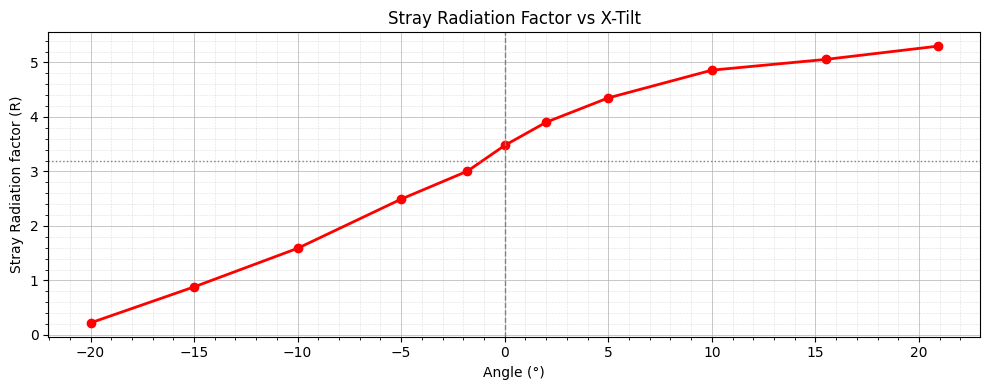

In [21]:
# ================================================================================================== Stray Radiation Plot =================================================================================================================

results_stray= []

for fit in fit_results:
    angle = fit["angle"]
    Ni_Ka_area = fit["Ni_Ka_area"]
    Mo_Ka_area = fit["Mo_Ka_area"]
    R_Ni_Mo = Ni_Ka_area / Mo_Ka_area

    results_stray.append({"angle": angle, "R_Ni_Mo": R_Ni_Mo})

    print(f"Angle = {angle:6.2f}°   " f"R_Ni_Mo = {R_Ni_Mo:.3f}")

R_Ni_Mo_avg = np.mean([r["R_Ni_Mo"] for r in results_stray])

print()
print(f"Average Stray Radiation factor (R) = {R_Ni_Mo_avg:.3f}")


# ================================================================================================== Stray Radiation vs Angle Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results_stray = sorted(results_stray, key=lambda r: r["angle"])

angles = np.array([r["angle"] for r in results_stray])
R_values = np.array([r["R_Ni_Mo"] for r in results_stray])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(angles, R_values, marker="o", linewidth=2, color="red")
ax.set_xlabel("Angle (°)")
ax.set_ylabel("Stray Radiation factor (R)")
ax.set_title("Stray Radiation Factor vs X-Tilt")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.axhline(R_Ni_Mo_avg, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
# plt.savefig(PlotPath / f"StrayRadiationFactorVsAngle_{timestamp}.pdf") # uncomment to save Vectrographics with timestamp
plt.show()

<center>

# Source of Stray Radiation
</center>

$$ R_{Mo_{K \alpha}/Mo_{L \alpha }} = \frac{I(Mo_{K \alpha})}{I(Mo_{L \alpha })}$$

High ratio (order of 100) indicates X-rays are main source of column radiation. If high energy electrons are predominant, the value is lower in the order of 1-10.

Angle = -20.00°   R_MoK_MoL = 2.500
Angle = -15.00°   R_MoK_MoL = 3.281
Angle = -10.00°   R_MoK_MoL = 2.599
Angle =  -5.00°   R_MoK_MoL = 2.454
Angle =  -1.80°   R_MoK_MoL = 2.393
Angle =   0.00°   R_MoK_MoL = 2.370
Angle =   2.00°   R_MoK_MoL = 2.278
Angle =   5.00°   R_MoK_MoL = 2.178
Angle =  10.00°   R_MoK_MoL = 2.105
Angle =  15.50°   R_MoK_MoL = 2.174
Angle =  20.90°   R_MoK_MoL = 2.214

Average Stray Radiation Source factor (R) = 2.413


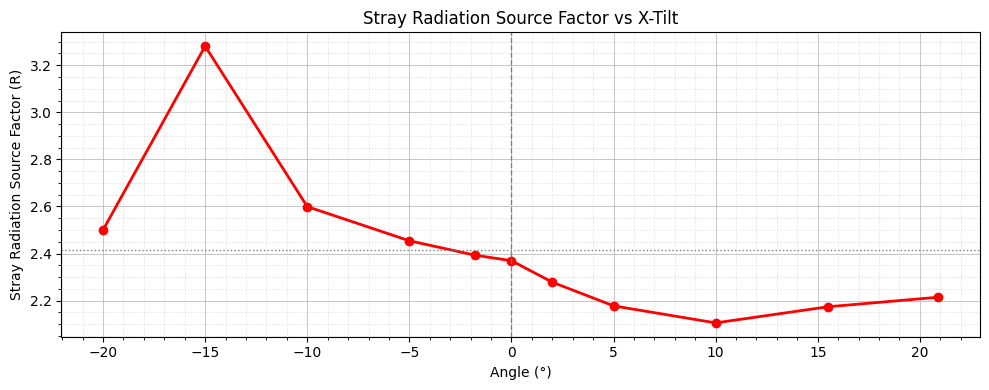

In [22]:
# ================================================================================================== Stray Radiation Source Plot ===========================================================================================================

results_straysource= []

for fit in fit_results:
    angle = fit["angle"]
    Mo_Ka_area = fit["Mo_Ka_area"]
    Mo_La_area = fit["Mo_La_area"]
    R_MoK_MoL =Mo_Ka_area / Mo_La_area

    results_straysource.append({"angle": angle, "R_MoK_MoL": R_MoK_MoL})

    print(f"Angle = {angle:6.2f}°   " f"R_MoK_MoL = {R_MoK_MoL:.3f}")

R_MoK_MoL_avg = np.mean([r["R_MoK_MoL"] for r in results_straysource])

print()
print(f"Average Stray Radiation Source factor (R) = {R_MoK_MoL_avg:.3f}")


# ================================================================================================== Stray Radiation Source vs Angle Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results_straysource = sorted(results_straysource, key=lambda r: r["angle"])

angles = np.array([r["angle"] for r in results_straysource])
R_values = np.array([r["R_MoK_MoL"] for r in results_straysource])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(angles, R_values, marker="o", linewidth=2, color="red")
ax.set_xlabel("Angle (°)")
ax.set_ylabel("Stray Radiation Source Factor (R)")
ax.set_title("Stray Radiation Source Factor vs X-Tilt")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.axhline(R_MoK_MoL_avg, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
# plt.savefig(PlotPath / f"StrayRadiationSourceFactorVsAngle_{timestamp}.pdf") # uncomment to save Vectrographics with timestamp
plt.show()

<center>

# Fiori Number ->  P/B Characteristics
</center>

$$ P/B_{10}= 60\cdot \frac{I(Ni_{K \alpha})}{B(Ni_{K \alpha })}\geq 1000 $$

$B_{10}=B_{600}/60$ Which Means the Background we use is the Average Background (whithout Peakarea) of one Channel over a Windwo width of 600eV


<!-- ATTENTION!

$$ \operatorname{erf}\left(\frac{2}{\sqrt{2}}\right)= 0.9545 $$

$$\sigma=\frac{FWHM}{2\sqrt{2\cdot ln(2)}}$$

X-Boundary for the Background

$$E_{1;2}=E_{Ni_{K\alpha}}\pm 2\cdot \sigma -->

Angle = -20.00°, Literature Energy Ni_Ka = 7.478, Experimental Energy Ni_Ka = 7.471, FWHM = 0.145,  PB = 222.619
Angle = -15.00°, Literature Energy Ni_Ka = 7.478, Experimental Energy Ni_Ka = 7.470, FWHM = 0.145,  PB = 750.932
Angle = -10.00°, Literature Energy Ni_Ka = 7.478, Experimental Energy Ni_Ka = 7.471, FWHM = 0.145,  PB = 1356.668
Angle =  -5.00°, Literature Energy Ni_Ka = 7.478, Experimental Energy Ni_Ka = 7.471, FWHM = 0.145,  PB = 1984.113
Angle =  -1.80°, Literature Energy Ni_Ka = 7.478, Experimental Energy Ni_Ka = 7.471, FWHM = 0.145,  PB = 2351.400
Angle =   0.00°, Literature Energy Ni_Ka = 7.478, Experimental Energy Ni_Ka = 7.471, FWHM = 0.145,  PB = 2525.086
Angle =   2.00°, Literature Energy Ni_Ka = 7.478, Experimental Energy Ni_Ka = 7.471, FWHM = 0.145,  PB = 2701.770
Angle =   5.00°, Literature Energy Ni_Ka = 7.478, Experimental Energy Ni_Ka = 7.471, FWHM = 0.145,  PB = 2883.215
Angle =  10.00°, Literature Energy Ni_Ka = 7.478, Experimental Energy Ni_Ka = 7.471, FWHM 

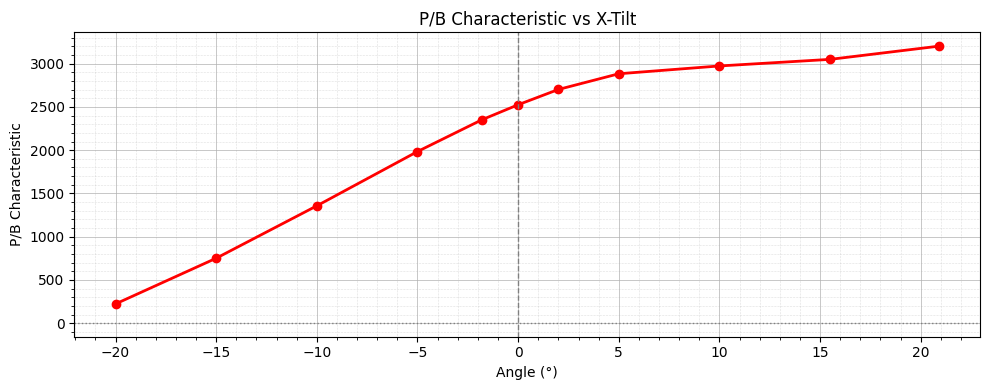

In [25]:
# ================================================================================================== P/B Characteristic Plot ==============================================================================================================


results_PBcharacteristics= []

E_N_Ka_true = s._get_line_energy("Ni_Ka")



for fit in fit_results:
    angle = fit["angle"]
    window=0.6
    x_Ni_bg_left = fit["Ni_Ka_mu"] - window/2
    x_Ni_bg_right = fit["Ni_Ka_mu"] + window/2

    bg_region = (x >= x_Ni_bg_left) & (x <= x_Ni_bg_right)
    total_background = (np.trapezoid(np.polyval(p_Ni, x[bg_region]), x[bg_region]) * KeV_per_channel) 
    Ni_Ka_area = fit["Ni_Ka_area"]* math.erf( 2 / math.sqrt(2))  #the first two means 2Simga equals 95.4% of the peak area, and the last term is the error function to account for the Gaussian distribution of the peak
    PB = 60*Ni_Ka_area / total_background

    results_PBcharacteristics.append({"angle": angle, "PB": PB})

    print(f"Angle = {angle:6.2f}°, Literature Energy Ni_Ka = {E_N_Ka_true:.3f}, Experimental Energy Ni_Ka = {fit["Ni_Ka_mu"]:.3f}, FWHM = {FWHM_Ni_Ka:.3f},  PB = {PB:.3f}")

PB_avg = np.mean([r["PB"] for r in results_PBcharacteristics])

print()
print(f"Average Stray Radiation factor (R) = {PB_avg:.3f}")

# ================================================================================================== P/B Characeristics vs Angle Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results_PBcharacteristics = sorted(results_PBcharacteristics, key=lambda r: r["angle"])

angles = np.array([r["angle"] for r in results_PBcharacteristics])
PB_values = np.array([r["PB"] for r in results_PBcharacteristics])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(angles, PB_values, marker="o", linewidth=2, color="red")
ax.set_xlabel("Angle (°)")
ax.set_ylabel("P/B Characteristic")
ax.set_title("P/B Characteristic vs X-Tilt")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.axhline(R_Ni_Mo_avg, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
# plt.savefig(PlotPath / f"PBCharacteristicsVsAngle_{timestamp}.pdf") # uncomment to save Vectrographics with timestamp

<center>

# Contamination or Icing of Detector
</center>

$$ R_{Ni_{K \alpha}/Ni_{L \alpha }} = \frac{I(Ni_{K \alpha})}{I(Ni_{L \alpha })}$$

Angle = -20.00°   R_NiK_NiL = 6.656
Angle = -15.00°   R_NiK_NiL = 2.108
Angle = -10.00°   R_NiK_NiL = 1.724
Angle =  -5.00°   R_NiK_NiL = 1.582
Angle =  -1.80°   R_NiK_NiL = 1.511
Angle =   0.00°   R_NiK_NiL = 1.464
Angle =   2.00°   R_NiK_NiL = 1.422
Angle =   5.00°   R_NiK_NiL = 1.339
Angle =  10.00°   R_NiK_NiL = 1.282
Angle =  15.50°   R_NiK_NiL = 1.257
Angle =  20.90°   R_NiK_NiL = 1.246

Average Contamination factor (R) = 1.963


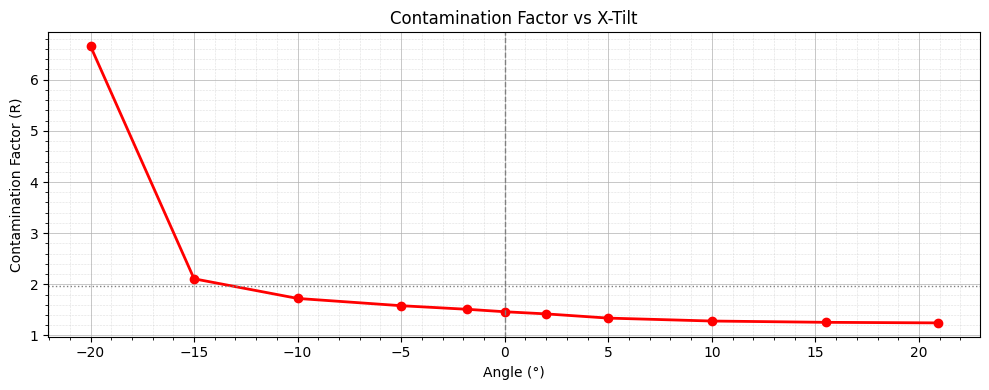

In [ ]:
# ================================================================================================== Contanimation Plot ===========================================================================================================

results_contanimation= []

for fit in fit_results:
    angle = fit["angle"]
    Ni_Ka_area = fit["Ni_Ka_area"]
    Ni_La_area = fit["Ni_La_area"]
    R_NiK_NiL = Ni_Ka_area / Ni_La_area

    results_contanimation.append({"angle": angle, "R_NiK_NiL": R_NiK_NiL})

    print(f"Angle = {angle:6.2f}°   " f"R_NiK_NiL = {R_NiK_NiL:.3f}")

R_NiK_NiL_avg = np.mean([r["R_NiK_NiL"] for r in results_contanimation])

print()
print(f"Average Contamination factor (R) = {R_NiK_NiL_avg:.3f}")


# ================================================================================================== Contamination vs Angle Plot ===============================================================================================================

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

results_contanimation = sorted(results_contanimation, key=lambda r: r["angle"])

angles = np.array([r["angle"] for r in results_contanimation])
R_values = np.array([r["R_NiK_NiL"] for r in results_contanimation])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(angles, R_values, marker="o", linewidth=2, color="red")
ax.set_xlabel("Angle (°)")
ax.set_ylabel("Contamination Factor (R)")
ax.set_title("Contamination Factor vs X-Tilt")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.axhline(R_NiK_NiL_avg, color="grey", linestyle=":", linewidth=1)
plt.tight_layout()
# plt.savefig(PlotPath / f"ContaminationFactorVsAngle_{timestamp}.pdf") # uncomment to save Vectrographics with timestamp
plt.show()

<center>

# Shadowing due to Tilting

</center>

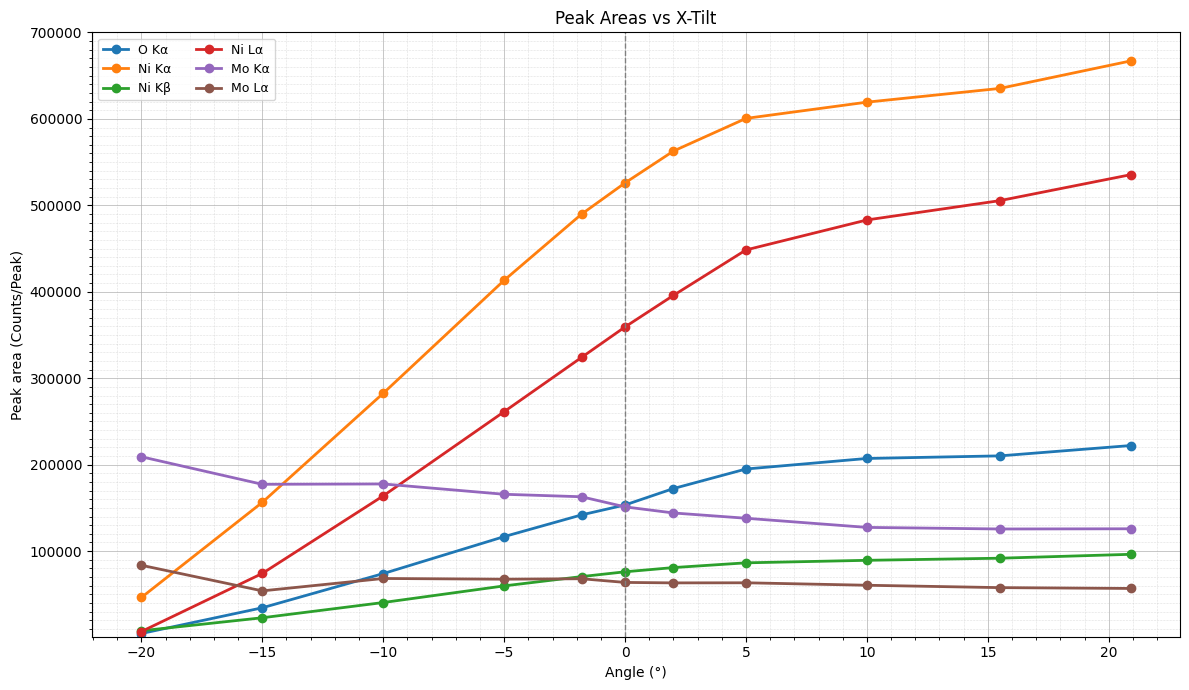

In [ ]:
# ==================================================================================================Peak Area vs Angle Plot==================================================================================================

results_peakareas = []

for fit in fit_results:
    results_peakareas.append({
        "angle": fit["angle"],
        "O_Ka_area": fit["O_Ka_area"],
        "Ni_Ka_area": fit["Ni_Ka_area"],
        "Ni_Kb_area": fit["Ni_Kb_area"],
        "Ni_La_area": fit["Ni_La_area"],
        "Mo_Ka_area": fit["Mo_Ka_area"],
        "Mo_La_area": fit["Mo_La_area"]
    })

results_peakareas = sorted(results_peakareas, key=lambda r: r["angle"])

angles = np.array([r["angle"] for r in results_peakareas])

O_Ka_area  = np.array([r["O_Ka_area"] for r in results_peakareas])
Ni_Ka_area = np.array([r["Ni_Ka_area"] for r in results_peakareas])
Ni_Kb_area = np.array([r["Ni_Kb_area"] for r in results_peakareas])
Ni_La_area = np.array([r["Ni_La_area"] for r in results_peakareas])
Mo_Ka_area = np.array([r["Mo_Ka_area"] for r in results_peakareas])
Mo_La_area = np.array([r["Mo_La_area"] for r in results_peakareas])

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(angles, O_Ka_area,  marker="o", linewidth=2, label="O Kα")
ax.plot(angles, Ni_Ka_area, marker="o", linewidth=2, label="Ni Kα")
ax.plot(angles, Ni_Kb_area, marker="o", linewidth=2, label="Ni Kβ")
ax.plot(angles, Ni_La_area, marker="o", linewidth=2, label="Ni Lα")
ax.plot(angles, Mo_Ka_area, marker="o", linewidth=2, label="Mo Kα")
ax.plot(angles, Mo_La_area, marker="o", linewidth=2, label="Mo Lα")

ax.set_xlabel("Angle (°)")
ax.set_ylabel("Peak area (Counts/Peak)")
ax.set_title("Peak Areas vs X-Tilt")

ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=1)
ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.75)

ax.axvline(0, color="grey", linestyle="--", linewidth=1)

ax.legend(ncol=2, fontsize=9)
ax.set_yscale("linear")
ax.set_ylim(bottom=1000)
ax.yaxis.set_minor_locator(MultipleLocator(10000))
plt.tight_layout()
# plt.savefig(PlotPath / f"PeakAreasVsAngle_{timestamp}.pdf") # uncomment to save Vectrographics with timestamp
plt.show()